In [3]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib

ROOT = pathlib.Path.cwd()
while not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
from astropy.table import Table, Column
from astropy import units as u
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
from crossmatching import Crossmatcher, EMCCatalog, EMCIdSupplier, SimbadIdSupplier, ParamFiller, temperate_mask, rocky_mask
from crossmatching.enrichment import (
    HpicParamSource, NeaParamSource, SimbadParamSource,
    EpicParamSource, ToiParamSource, EuParamSource
)
from crossmatching.enrichment import classify_spectral_type
from collections import Counter
import glob
import ipydatagrid
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly
from matplotlib.patches import Rectangle
from IPython.display import display, HTML
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly
mpl.rcParams['figure.dpi'] = 300


In [4]:
# Habitable zone flux limits in S/S_earth — Kopparapu et al. (2014), optimistic bounds
HZ_INNER = 1.7   # inner (hot) edge — Recent Venus
HZ_OUTER = 0.35  # outer (cold) edge — Early Mars

# Set True to include planets where the flux_rel ± uncertainty interval overlaps
# the HZ (i.e. could be temperate within measurement error), False for strict central-value test.
USE_INTERVAL_HZ = True

# Set True to include planets with only msini-derived radius bounds overlapping
# the rocky range (uncertain rocky), False for confirmed transit radius only.
USE_INTERVAL_ROCKY = True

CATEGORY_COLORS = {
    'Sun-like':            '#F5A623',
    'Low-luminosity':      '#E05C00',
    'Very-low-luminosity': '#C0392B',
    'Other':               '#95A5A6',
}
CATEGORY_ORDER = ['Very-low-luminosity', 'Low-luminosity', 'Sun-like', 'Other']

In [5]:
input_table = Table.read('./input/HPIC_LC4_combined_d50.txt', format='ascii',)
cme = Crossmatcher(EMCCatalog(), EMCIdSupplier())

cme.load_catalog(from_file='./input/exo-mercat.csv', format='csv')
cme.load_alternate_ids(input_table['star_name'].tolist(), from_file='./input/exo-mercat.csv')

input_table = cme.remove_duplicates(input_table, input_starname_key='star_name')
out_emc = cme.combined_crossmatch(input_table, input_starname_key='star_name')  

In [6]:
nea_src = NeaParamSource()
nea_src.load(from_file='././input/pscomppars.txt', format='ascii')
print(f'NEA planets loaded:     {len(nea_src._lookup):,}')
print(f'With insol:             {sum(1 for v in nea_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in nea_src._lookup.values() if "teff" in v and "rad" in v):,}')


# Tier 3
eu_src = EuParamSource()
eu_path = sorted(glob.glob('../Exo-MerCat/InputSources/eu_init*.csv'))[-1]
eu_src.load(from_file=eu_path, format="ascii.csv")
print(f"\nEU planets loaded: {len(eu_src._lookup):,}")

# ── Tier 2: EPIC (K2 planets not in NEA) ─────────────────────────────────────
epic_src = EpicParamSource()
epic_path = sorted(glob.glob('../Exo-MerCat/InputSources/epic_init*.csv'))[-1]
epic_src.load(from_file=epic_path, format='ascii.csv')
print(f'\nEPIC planets loaded:    {len(epic_src._lookup):,}')
print(f'With insol:             {sum(1 for v in epic_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in epic_src._lookup.values() if "teff" in v and "rad" in v):,}')
# ── Tier 3: TOI (TESS objects) ────────────────────────────────────────────────
# ── Tier 3: TOI (TESS objects) ────────────────────────────────────────────────
toi_src = ToiParamSource()
toi_path = sorted(glob.glob('../Exo-MerCat/InputSources/toi_init*.csv'))[-1]
toi_src.load(from_file=toi_path, format='ascii.csv')
print(f'\nTOI entries loaded:     {len(toi_src._lookup):,}')
print(f'With insol:             {sum(1 for v in toi_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in toi_src._lookup.values() if "teff" in v and "rad" in v):,}')

# ── Tier 4: SIMBAD fallback ───────────────────────────────────────────────────
simbad_src = SimbadParamSource()
simbad_src.load(from_file='./input/simbad_params.txt')
print(f'SIMBAD matches: {len(simbad_src._lookup):,}')

merger = ParamFiller([nea_src, eu_src, epic_src, toi_src, simbad_src])

NEA planets loaded:     6,298
With insol:             4,413
With teff + rad:        5,977

EU planets loaded: 11,190

EPIC planets loaded:    1,806
With insol:             175
With teff + rad:        1,230

TOI entries loaded:     8,064
With insol:             7,878
With teff + rad:        7,429
SIMBAD matches: 8,924


In [7]:
e_cm_emc = merger.enrich(
    out_emc,
    **EMCCatalog.ENRICH_KEYS,
    id_supplier=cme.id_supplier,
    alternate_ids=cme.alternate_ids
)[0]
e_emc = merger.enrich(
    cme.catalog_table,
    **EMCCatalog.ENRICH_KEYS,
    id_supplier=cme.id_supplier,
    alternate_ids=cme.alternate_ids
)[0]
len(e_cm_emc), len(e_emc)

(1261, 16132)

In [8]:
def compute_is_rocky_temperate(catalog):
    catalog['mass_earth'] = catalog['mass'] * u.M_jupiter.to(u.M_earth)
    catalog['msini_earth'] = catalog['msini'] * u.M_jupiter.to(u.M_earth)
    catalog['r_earth'] = catalog['r'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_max'] = catalog['r_max'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_min'] = catalog['r_min'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_lower_bound'] = catalog['r_lower_bound'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_upper_bound'] = catalog['r_upper_bound'] * u.R_jupiter.to(u.R_earth)

    rocky_confirmed = rocky_mask(
        catalog['r_earth'], catalog['r_earth_min'], catalog['r_earth_max'], catalog['r_earth_lower_bound'], catalog['r_earth_upper_bound'],
        use_interval=False
    )
    rocky_uncertain = rocky_mask(
        catalog['r_earth'], catalog['r_earth_min'], catalog['r_earth_max'], catalog['r_earth_lower_bound'], catalog['r_earth_upper_bound'],
        use_interval=True
    )
    catalog['is_rocky'] = Column([''] * len(catalog), dtype="U10")
    catalog['is_rocky'][rocky_uncertain] = ['Uncertain'] * sum(rocky_uncertain)
    catalog['is_rocky'][rocky_confirmed] = ['Confirmed'] * sum(rocky_confirmed)


    temperate_confirmed = temperate_mask(
        catalog['pl_insol'], catalog['pl_insol_max'], catalog['pl_insol_min'],
        HZ_OUTER, HZ_INNER,
        use_interval=False
    )
    temperate_uncertain = temperate_mask(
        catalog['pl_insol'], catalog['pl_insol_max'], catalog['pl_insol_min'],
        HZ_OUTER, HZ_INNER,
        use_interval=True
    )
    catalog['is_temperate'] = Column([''] * len(catalog), dtype="U10")
    catalog['is_temperate'][temperate_uncertain] = ['Uncertain'] * sum(temperate_uncertain)
    catalog['is_temperate'][temperate_confirmed] = ['Confirmed'] * sum(temperate_confirmed)

    emc_confirmed = catalog["status"] == "CONFIRMED"
    rocky_temp_uncertain = temperate_uncertain & rocky_uncertain 
    rocky_temp_confirmed = temperate_confirmed & rocky_confirmed & emc_confirmed
    catalog['rocky_temp_status'] = Column([''] * len(catalog), dtype="U10")
    catalog['rocky_temp_status'][rocky_temp_uncertain] = ["Uncertain"] * sum(rocky_temp_uncertain)
    catalog['rocky_temp_status'][rocky_temp_confirmed] = ["Confirmed"] * sum(rocky_temp_confirmed)


compute_is_rocky_temperate(e_cm_emc)
compute_is_rocky_temperate(e_emc)

print("Total Number of Rocky and Temperate Planets")
print("\t Crossmatched \t    all EMC")
print(f"Confirmed:\t{sum(e_cm_emc['rocky_temp_status'] == 'Confirmed')}\t\t{sum(e_emc['rocky_temp_status'] == 'Confirmed')}" ) 
print(f"Uncertain:\t{sum(e_cm_emc['rocky_temp_status'] == 'Uncertain')}\t\t{sum(e_emc['rocky_temp_status'] == 'Uncertain')}" ) 



Total Number of Rocky and Temperate Planets
	 Crossmatched 	    all EMC
Confirmed:	7		17
Uncertain:	13		66


In [9]:
def _log_heatmap(x_raw, y_raw, log_x_edges, log_y_edges, **kwargs):
    """2D histogram binned in log-space with explicit edges and log color scale, returned as a Heatmap trace."""
    mask = (x_raw > 0) & (y_raw > 0)
    x, y = x_raw[mask], y_raw[mask]
    counts, _, _ = np.histogram2d(np.log10(x), np.log10(y), bins=[log_x_edges, log_y_edges])
    x_centers = 10 ** ((log_x_edges[:-1] + log_x_edges[1:]) / 2)
    y_centers = 10 ** ((log_y_edges[:-1] + log_y_edges[1:]) / 2)
    z_log = np.log10(counts.T + 1)
    return go.Heatmap(x=x_centers, y=y_centers, z=z_log, **kwargs)


def double_hist_heatmap(catalog1: Table, catalog2: Table, catalog1_name: str, catalog2_name: str, **kwargs):
    # Compute shared bin edges from the union of both datasets
    n_bins_x = 60
    n_bins_y = 45
    log_x_edges = np.linspace(np.log10(0.3), np.log10(100), n_bins_x + 1)
    log_y_edges = np.linspace(np.log10(0.01), np.log10(10000), n_bins_y + 1)

    cat1_mask = catalog1['r_earth'].mask | catalog1['pl_insol'].mask
    cat2_mask = catalog2['r_earth'].mask | catalog2['pl_insol'].mask



    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(catalog1_name, catalog2_name),
        specs=[[{}, {}]]
    )

    fig.add_trace(_log_heatmap(
            catalog1['r_earth'][~cat1_mask],
            catalog1['pl_insol'][~cat1_mask],
            log_x_edges,
            log_y_edges,
            showscale=True,
            colorscale='Blackbody',
            coloraxis='coloraxis',
            hovertemplate="r: %{x:.2f}<br>F: %{y:.2f}<br>log₁₀(Count): %{z:.2f}<extra></extra>",
            name='HPIC crossmatched with Exo-MerCat'
        ), row=1, col=1
    )

    fig.add_trace(_log_heatmap(
            catalog2['r_earth'][~cat2_mask],
            catalog2['pl_insol'][~cat2_mask],
            log_x_edges,
            log_y_edges,
            colorscale='Blackbody',
            showscale=False,
            coloraxis='coloraxis',
            hovertemplate="r: %{x:.2f}<br>F: %{y:.2f}<br>log₁₀(Count): %{z:.2f}<extra></extra>",
            name='Exo-MerCat'
        ), row=1, col=2
    )

    # Add habitable zone rectangles
    for col in [1, 2]:
        fig.add_shape(
            type="rect",
            x0=0.5, x1=1.5,
            y0=HZ_OUTER, y1=HZ_INNER,
            line=dict(color="red", width=1.5),
            fillcolor="rgba(255, 0, 0, 0.12)",
            xref=f"x{col}", yref=f"y{col}",
            row=1, col=col
        )

    # Update axes for both subplots with linked zoom
    for i in [1, 2]:
        fig.update_xaxes(
            type="log", title_text=r"$R_p \; [R_\oplus]$", matches='x', row=1, col=i,
            tickvals=[0.1, 0.3, 0.5, 1, 1.5, 3, 5, 10, 25, 100],
            # ticktext=['0.1', '0.3', '1', '3', '10', '25'],
        )
        fig.update_yaxes(
            type="log", title_text=r"$S_p [S_\oplus]$" if i == 1 else "", matches='y', row=1, col=i,
            tickvals=[0.01, 0.1, HZ_INNER, 1, HZ_OUTER, 10, 100, 1000, 10000],
            # ticktext=['0.01', '0.1', '1', '10', '100', '1000', '10000'],
        )

    fig.update_layout(
        hovermode='closest',
        coloraxis=dict(
            # overriding 'Inferno' to better suit my preferences
            colorscale=[
                [0.0, "#000000"],
                [0.1, "#000000"],
                [0.15, "#420a68"],
                [0.2, "#6a176e"],
                [0.3, "#932667"],
                [0.45, "#bc3754"],
                [0.6, "#dd513a"],
                [0.7, "#f37819"],
                [0.8, "#fca50a"],
                [0.9, "#f6d746"],
                [1.0, "#fcffa4"],
            ],
            colorbar=dict(
                title="Count",
                x=0.46,
                tickvals=[0, 0.3, np.log10(10), np.log10(100), np.log10(1000)],
                ticktext=['0', '1', '10', '100', '1000']
            )
        ),
        **kwargs
    )

    fig.show()

double_hist_heatmap(e_cm_emc, e_emc, catalog1_name=r"$\text{HPIC} \otimes \text{EMC}$", catalog2_name="entire Exo-MerCat", width=1200, height=500, title="Exoplanet Distribution Heatmap")

In [10]:
double_hist_heatmap(e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] < 50], e_emc, catalog1_name="EMC < 50", catalog2_name="entire Exo-MerCat", width=1200, height=500, title="Exoplanet Distribution Heatmap")

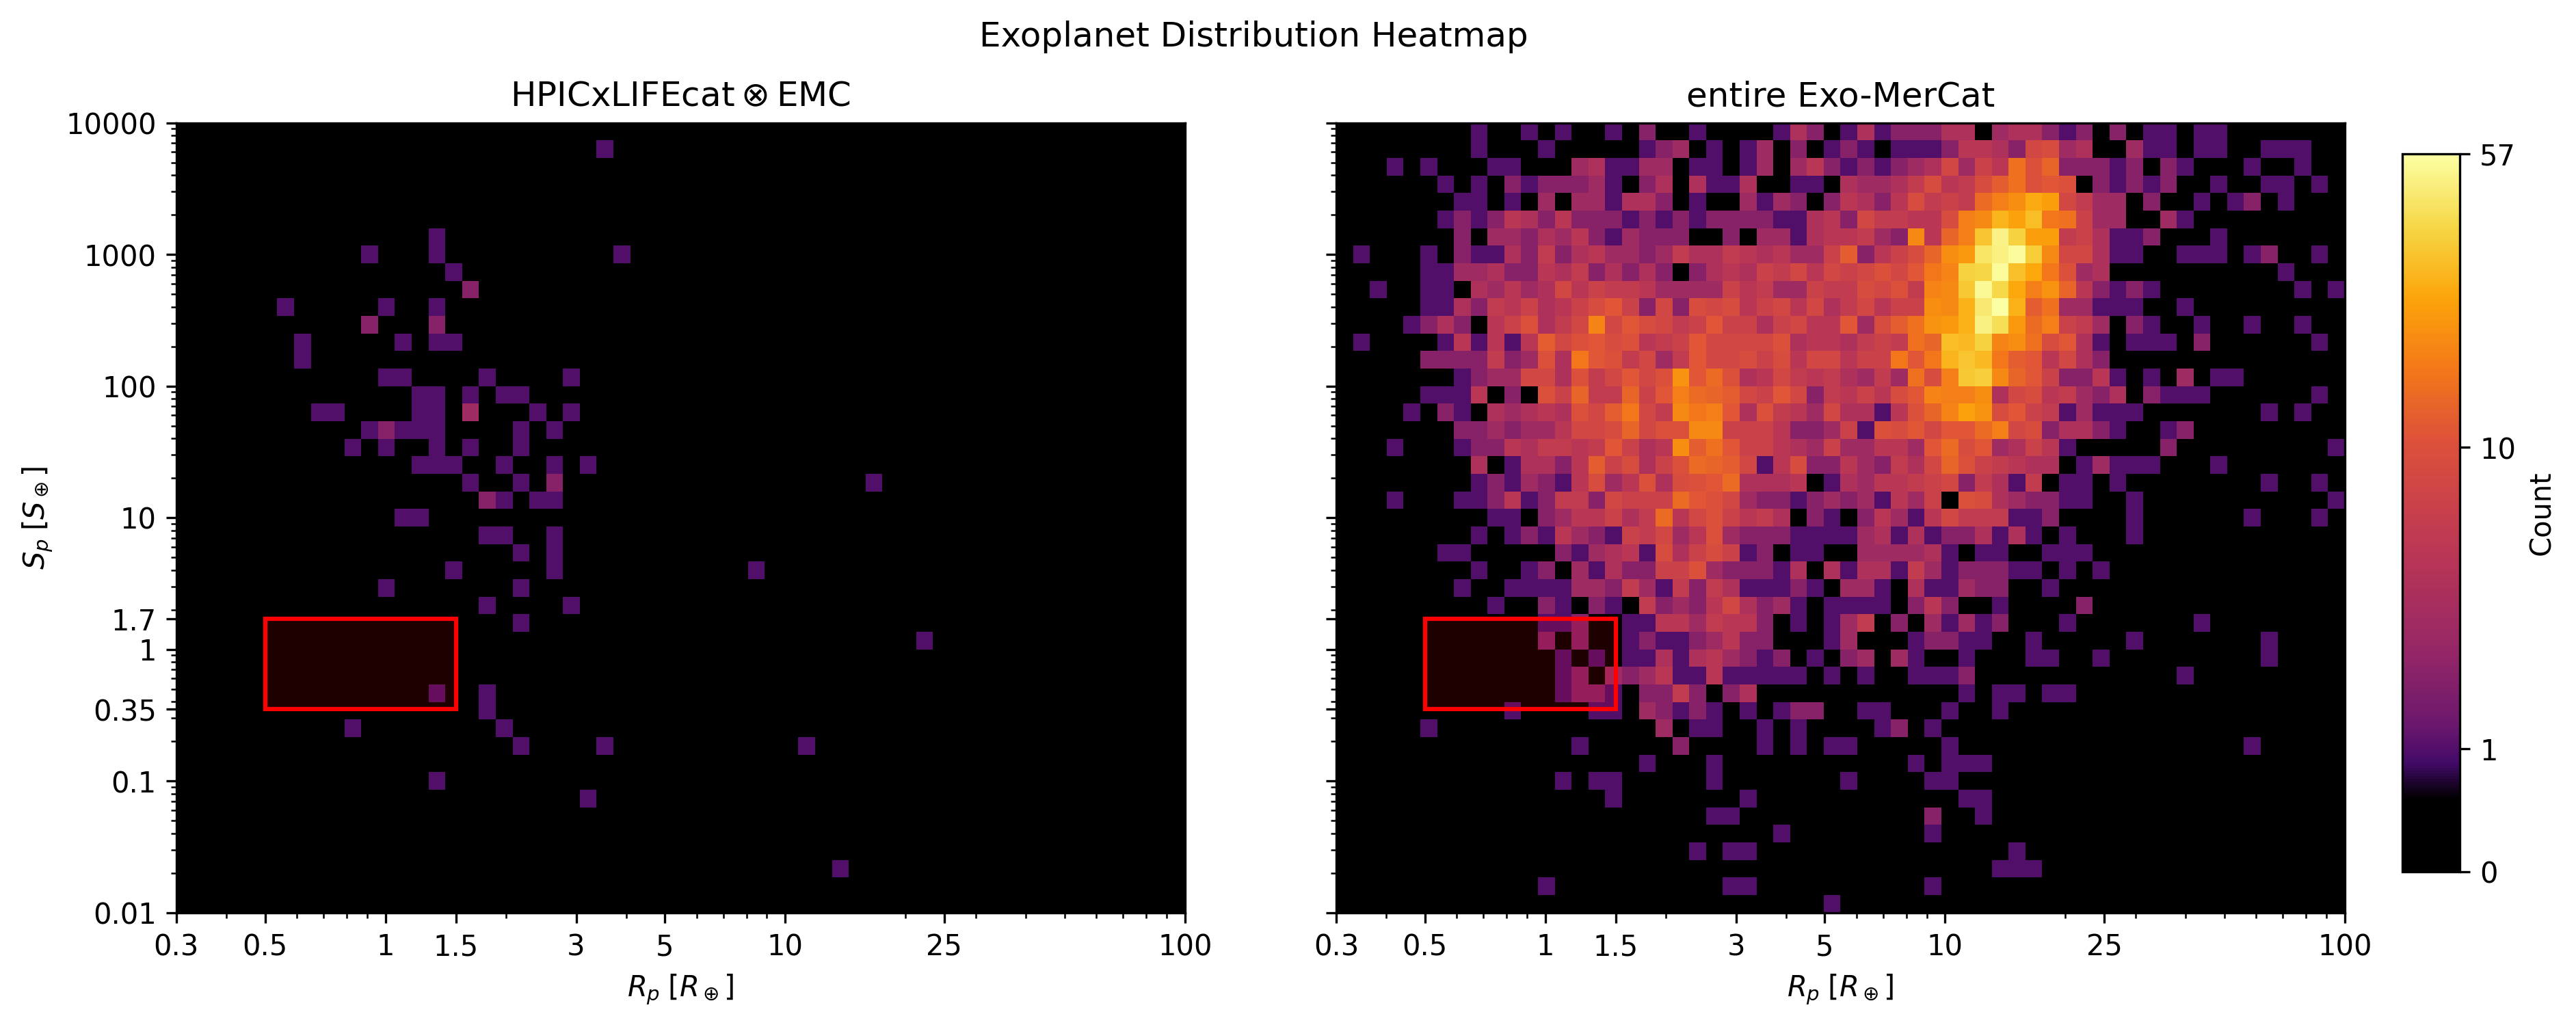

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.ticker import FixedLocator, FixedFormatter

_CMAP = LinearSegmentedColormap.from_list(
    "custom_inferno",
    [
        (0.0, "#000000"), (0.1, "#000000"), (0.15, "#420a68"),
        (0.2, "#6a176e"), (0.3, "#932667"), (0.45, "#bc3754"),
        (0.6, "#dd513a"), (0.7, "#f37819"), (0.8, "#fca50a"),
        (0.9, "#f6d746"), (1.0, "#fcffa4"),
    ],
)


def _log_hist2d(x_raw, y_raw, log_x_edges, log_y_edges):
    """2D histogram binned in log-space; returns (x_edges, y_edges, log10(counts+1))."""
    mask = (x_raw > 0) & (y_raw > 0)
    x, y = x_raw[mask], y_raw[mask]
    counts, _, _ = np.histogram2d(np.log10(x), np.log10(y), bins=[log_x_edges, log_y_edges])
    x_edges = 10 ** log_x_edges
    y_edges = 10 ** log_y_edges
    z_log = np.log10(counts.T + 1)
    return x_edges, y_edges, z_log


def double_hist_heatmap(catalog1, catalog2, catalog1_name, catalog2_name, figsize=(12, 5), title=None):
    n_bins_x = 60
    n_bins_y = 45
    log_x_edges = np.linspace(np.log10(0.3), np.log10(100), n_bins_x + 1)
    log_y_edges = np.linspace(np.log10(0.01), np.log10(10000), n_bins_y + 1)

    cat1_mask = catalog1['r_earth'].mask | catalog1['pl_insol'].mask
    cat2_mask = catalog2['r_earth'].mask | catalog2['pl_insol'].mask

    # compute both histograms up front so the shared color scale can be
    # derived from the true combined max, matching Plotly's auto-ranged coloraxis
    x1_edges, y1_edges, z1 = _log_hist2d(catalog1['r_earth'][~cat1_mask], catalog1['pl_insol'][~cat1_mask], log_x_edges, log_y_edges)
    x2_edges, y2_edges, z2 = _log_hist2d(catalog2['r_earth'][~cat2_mask], catalog2['pl_insol'][~cat2_mask], log_x_edges, log_y_edges)
    vmax = max(z1.max(), z2.max())

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

    mesh = None
    for ax, x_edges, y_edges, z_log, name in zip(
        axes, [x1_edges, x2_edges], [y1_edges, y2_edges], [z1, z2], [catalog1_name, catalog2_name]
    ):
        mesh = ax.pcolormesh(x_edges, y_edges, z_log, cmap=_CMAP, vmin=0, vmax=vmax, shading='flat')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(name)

        ax.add_patch(Rectangle(
            (0.5, min(HZ_OUTER, HZ_INNER)), 1.0, abs(HZ_INNER - HZ_OUTER),
            edgecolor=(1, 0, 0, 1.0),      # opaque red border
            facecolor=(1, 0, 0, 0.12),     # translucent red fill
            linewidth=1.5
        ))
        xticks = [0.1, 0.3, 0.5, 1, 1.5, 3, 5, 10, 25, 100]
        yticks = [0.01, 0.1, HZ_INNER, 1, HZ_OUTER, 10, 100, 1000, 10000]
        ax.xaxis.set_major_locator(FixedLocator(xticks))
        ax.xaxis.set_major_formatter(FixedFormatter([str(v) for v in xticks]))
        ax.yaxis.set_major_locator(FixedLocator(yticks))
        ax.yaxis.set_major_formatter(FixedFormatter([str(v) for v in yticks]))
        ax.set_xlabel(r"$R_p \; [R_\oplus]$")

    axes[0].set_ylabel(r"$S_p \; [S_\oplus]$")

    fig.subplots_adjust(right=0.88, wspace=0.15)
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Count")

    # colorbar ticks at fixed count values, but only up to the actual vmax
    tick_counts = [c for c in [0, 1, 10, 100, 1000] if np.log10(c + 1) < vmax - 1e-9]
    top_count = round(10 ** vmax - 1)          # actual max count, back-converted from vmax
    tick_counts.append(top_count)

    cbar.set_ticks([np.log10(c + 1) for c in tick_counts])
    cbar.set_ticklabels([str(c) for c in tick_counts])

    if title:
        fig.suptitle(title)

    plt.show()


double_hist_heatmap(
    e_cm_emc[e_cm_emc["status"] != "CONFIRMED"], e_emc[e_emc["status"] != "CONFIRMED"],
    catalog1_name=r"$\text{HPICxLIFEcat} \otimes \text{EMC}$",
    catalog2_name="entire Exo-MerCat",
    title="Exoplanet Distribution Heatmap",
    figsize=(14,5)
)



In [12]:
e_emc_d50 = e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] <= 50]

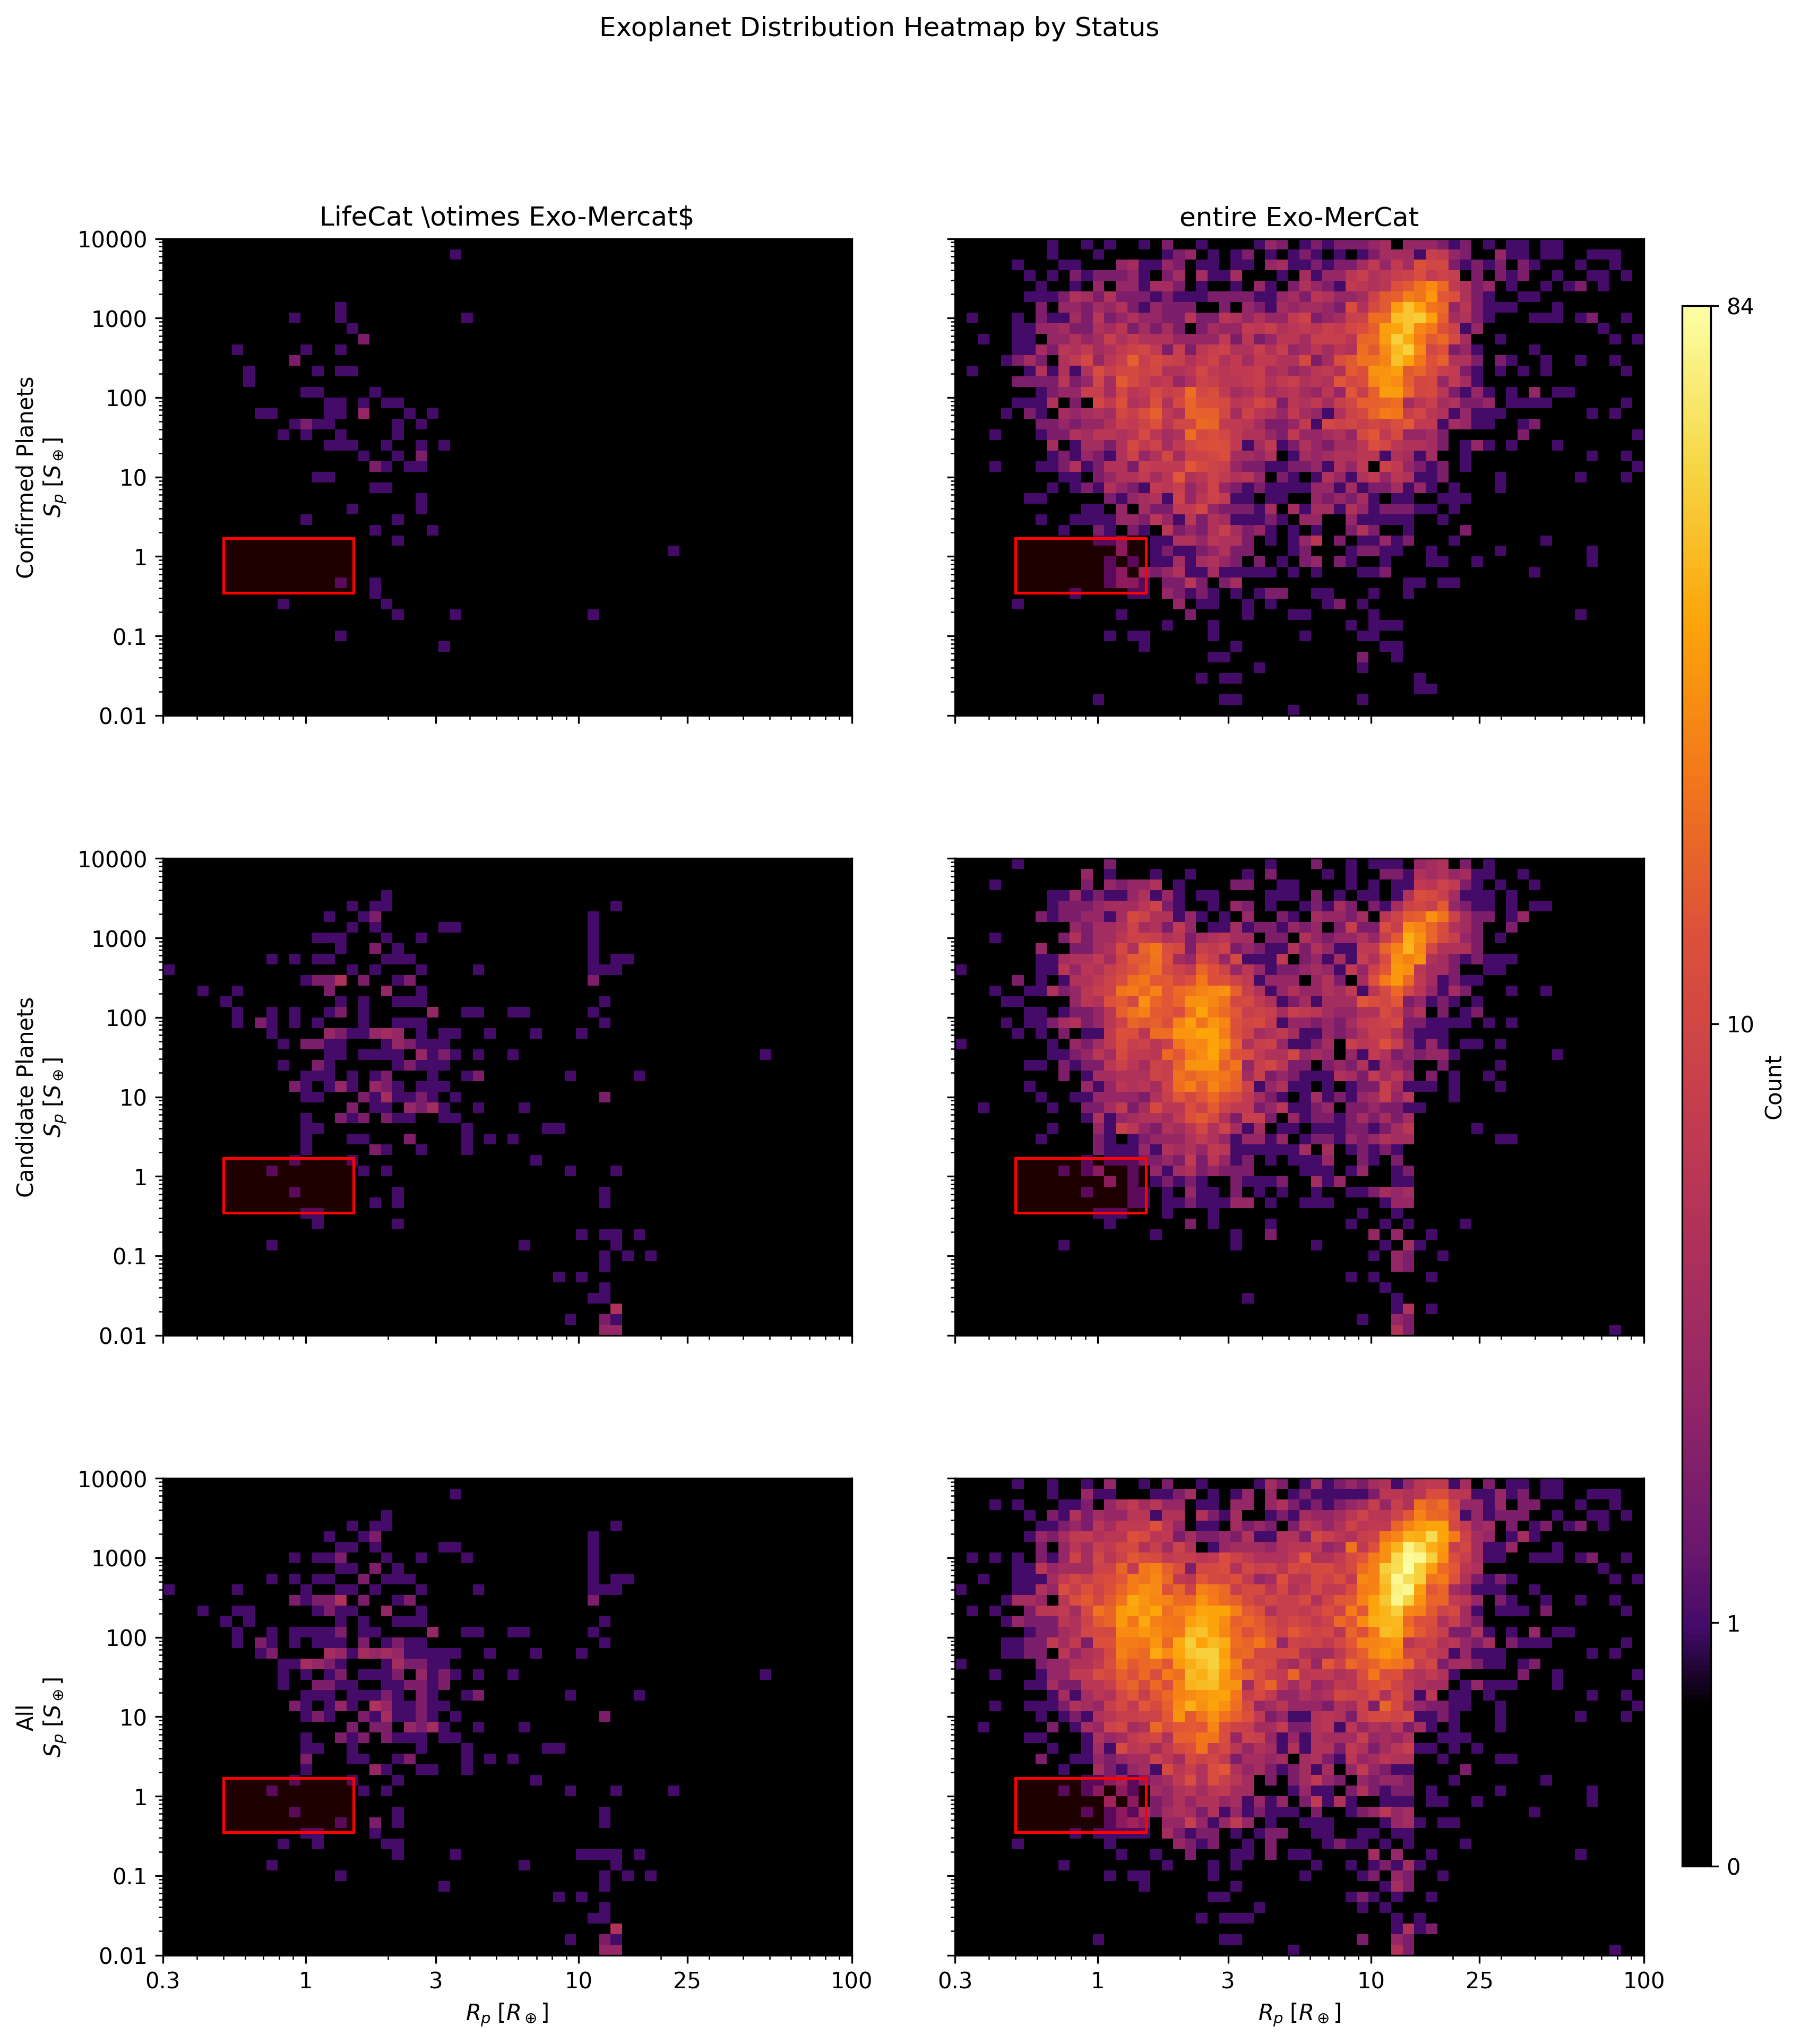

In [13]:
def status_grid_heatmap(catalogs, names, figsize=None, title=None):
    n_bins_x, n_bins_y = 60, 45
    log_x_edges = np.linspace(np.log10(0.3), np.log10(100), n_bins_x + 1)
    log_y_edges = np.linspace(np.log10(0.01), np.log10(10000), n_bins_y + 1)

    if figsize is None:
        figsize = (5 * len(catalogs) + 2, 14)  # scale width with number of columns

    row_specs = [
        ("Confirmed Planets", lambda s: s == "CANDIDATE"),
        ("Candidate Planets", lambda s: s != "CANDIDATE"),
        ("All", lambda s: np.ones(len(s), dtype=bool)),
    ]

    grid_data = []
    vmax = 0
    for _, status_filter in row_specs:
        row_data = []
        for cat in catalogs:
            nan_mask = cat['r_earth'].mask | cat['pl_insol'].mask
            keep = status_filter(cat['status']) & (~nan_mask)
            x_edges, y_edges, z = _log_hist2d(cat['r_earth'][keep], cat['pl_insol'][keep], log_x_edges, log_y_edges)
            row_data.append((x_edges, y_edges, z))
            vmax = max(vmax, z.max())
        grid_data.append(row_data)

    n_cols = len(catalogs)
    fig, axes = plt.subplots(3, n_cols, figsize=figsize, sharex=True, sharey=True)

    mesh = None
    xticks = [0.3, 1, 3, 10, 25, 100]
    yticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
    for i, (row_name, _) in enumerate(row_specs):
        for j, cat_name in enumerate(names):
            ax = axes[i, j]
            x_edges, y_edges, z = grid_data[i][j]
            mesh = ax.pcolormesh(x_edges, y_edges, z, cmap=_CMAP, vmin=0, vmax=vmax, shading='flat')
            ax.set_xscale('log')
            ax.set_yscale('log')

            if i == 0:
                ax.set_title(cat_name)
            if j == 0:
                ax.set_ylabel(f"{row_name}\n" + r"$S_p \; [S_\oplus]$")
            if i == len(row_specs) - 1:
                ax.set_xlabel(r"$R_p \; [R_\oplus]$")

            ax.add_patch(Rectangle(
                (0.5, min(HZ_OUTER, HZ_INNER)), 1.0, abs(HZ_INNER - HZ_OUTER),
                edgecolor=(1, 0, 0, 1.0), facecolor=(1, 0, 0, 0.12), linewidth=1.2
            ))

            ax.xaxis.set_major_locator(FixedLocator(xticks))
            ax.xaxis.set_major_formatter(FixedFormatter([str(v) for v in xticks]))
            ax.yaxis.set_major_locator(FixedLocator(yticks))
            ax.yaxis.set_major_formatter(FixedFormatter([str(v) for v in yticks]))

    fig.subplots_adjust(right=0.90, wspace=0.15, hspace=0.3)
    cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Count")
    tick_counts = [c for c in [0, 1, 10, 100, 1000] if np.log10(c + 1) < vmax - 1e-9]
    top_count = round(10 ** vmax - 1)          # actual max count, back-converted from vmax
    tick_counts.append(top_count)

    cbar.set_ticks([np.log10(c + 1) for c in tick_counts])
    cbar.set_ticklabels([str(c) for c in tick_counts])
    if title:
        fig.suptitle(title)
    # plt.tight_layout()
    plt.show()

status_grid_heatmap(
    [e_cm_emc,  e_emc],
    [r"LifeCat \otimes Exo-Mercat$", "entire Exo-MerCat"],
    title="Exoplanet Distribution Heatmap by Status",
)

In [14]:
e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] < 50][e_emc["sy_dist"][e_emc["sy_dist"] - e_emc["sy_dist_min"] < 50].argmax()]

exo-mercat_name,nasa_name,toi_name,epic_name,eu_name,oec_name,host,letter,main_id,binary,main_id_ra,main_id_dec,mass,mass_max,mass_min,mass_url,msini,msini_max,msini_min,msini_url,bestmass,bestmass_max,bestmass_min,bestmass_url,bestmass_provenance,p,p_max,p_min,p_url,r,r_max,r_min,r_url,a,a_max,a_min,a_url,e,e_max,e_min,e_url,i,i_max,i_min,i_url,discovery_method,status,checked_status_string,original_status_string,confirmed,discovery_year,main_id_aliases,main_id_provenance,angular_separation_flag,angular_separation,catalog,duplicate_catalog_flag,duplicate_names,binary_coordinate_mismatch_flag,binary_complex_system_flag,coordinate_mismatch_flag,coordinate_mismatch,period_mismatch_flag,fallback_merge_flag,misnamed_duplicates_flag,row_update,st_rad,st_rad_src,st_rad_max,st_rad_min,st_mass,st_mass_src,st_mass_max,st_mass_min,st_teff,st_teff_src,st_teff_max,st_teff_min,st_logg,st_logg_src,st_logg_max,st_logg_min,st_met,st_met_src,st_met_max,st_met_min,st_lum,st_lum_src,st_lum_max,st_lum_min,sy_vmag,sy_vmag_src,sy_vmag_max,sy_vmag_min,sy_kmag,sy_kmag_src,sy_kmag_max,sy_kmag_min,sy_dist,sy_dist_src,sy_dist_max,sy_dist_min,pl_insol,pl_insol_src,pl_insol_max,pl_insol_min,pl_eqt,pl_eqt_src,pl_eqt_max,pl_eqt_min,a_src,r_src,pl_mass,pl_mass_src,pl_mass_max,pl_mass_min,msini_src,p_src,r_lower_bound,r_lower_bound_src,r_upper_bound,r_upper_bound_src,st_spectype,st_spectype_src,normalized_st_spectype,spectral_category,mass_earth,msini_earth,r_earth,r_earth_max,r_earth_min,r_earth_lower_bound,r_earth_upper_bound,is_rocky,is_temperate,rocky_temp_status
str39,str28,str11,str19,str31,str27,str29,str3,str36,str6,float64,float64,float64,float64,float64,str50,float64,float64,float64,str21,float64,float64,float64,str50,str5,float64,float64,float64,str67,float64,float64,float64,str67,float64,float64,float64,str67,float64,float64,float64,str67,float64,float64,float64,str67,str39,str14,str95,str95,int64,int64,str1562,str11,int64,str45,str20,int64,str101,int64,int64,int64,str3,int64,int64,int64,str10,float64,str45,float64,float64,float64,str61,float64,float64,float64,str41,float64,float64,float64,str6,float64,float64,float64,str6,float64,float64,float64,str93,float64,float64,float64,str6,float64,float64,float64,str6,float64,float64,float64,str6,float64,float64,float64,str144,float64,float64,float64,str159,float64,float64,str87,str5,float64,str3,float64,float64,str5,str5,float64,str25,float64,str32,str5,str6,str5,str19,float64,float64,float64,float64,float64,float64,float64,str10,str10,str10
CRTS J160146.7-202642 .01,--,--,EPIC 204880394.01,--,--,EPIC 204880394,.01,CRTS J160146.7-202642,--,240.44457619003998,-20.444738542349995,--,--,--,--,--,--,--,--,--,--,--,--,--,0.2338108,1e-05,9.8e-06,2019ApJS..244...11K,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,Transit,CANDIDATE,epic: CANDIDATE,epic: CANDIDATE,0,2019,"2MASS J16014668-2026412,CRTS J160146.7-202642,EPIC 204880394,Gaia DR2 6247076008441340288,Gaia DR3 6247076008441340288,TIC 9669622,ZTF J160146.69-202641.0,[DCD2013] MLS J160146.7-202640,[SHM2017] J240.44458-20.44473",SIMBAD,0,epic: 0.0,epic,0,--,0,0,0,--,0,0,0,2026-05-31,--,,--,--,--,,--,--,--,,--,--,--,,--,--,--,,--,--,--,,--,--,18.3374,epic,0.0587,0.0587,15.38,epic,--,--,133333.33333333334,simbad,3164444.4995456273,3164444.4995456273,--,,--,--,--,,--,--,,,--,,--,--,,input,--,,--,,--,,,Other,--,--,--,--,--,--,--,,,


In [15]:
def compute_is_rocky_temperate(catalog):
    catalog['mass_earth'] = catalog['mass'] * u.M_jupiter.to(u.M_earth)
    catalog['msini_earth'] = catalog['msini'] * u.M_jupiter.to(u.M_earth)
    catalog['r_earth'] = catalog['r'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_max'] = catalog['r_max'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_min'] = catalog['r_min'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_lower_bound'] = catalog['r_lower_bound'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_upper_bound'] = catalog['r_upper_bound'] * u.R_jupiter.to(u.R_earth)

    rocky_confirmed = rocky_mask(
        catalog['r_earth'], catalog['r_earth_min'], catalog['r_earth_max'], catalog['r_earth_lower_bound'], catalog['r_earth_upper_bound'],
        use_interval=False
    )
    rocky_uncertain = rocky_mask(
        catalog['r_earth'], catalog['r_earth_min'], catalog['r_earth_max'], catalog['r_earth_lower_bound'], catalog['r_earth_upper_bound'],
        use_interval=True
    )
    catalog['is_rocky'] = Column([''] * len(catalog), dtype="U10")
    catalog['is_rocky'][rocky_uncertain] = ['Uncertain'] * sum(rocky_uncertain)
    catalog['is_rocky'][rocky_confirmed] = ['Confirmed'] * sum(rocky_confirmed)


    temperate_confirmed = temperate_mask(
        catalog['pl_insol'], catalog['pl_insol_max'], catalog['pl_insol_min'],
        HZ_OUTER, HZ_INNER,
        use_interval=False
    )
    temperate_uncertain = temperate_mask(
        catalog['pl_insol'], catalog['pl_insol_max'], catalog['pl_insol_min'],
        HZ_OUTER, HZ_INNER,
        use_interval=True
    )
    catalog['is_temperate'] = Column([''] * len(catalog), dtype="U10")
    catalog['is_temperate'][temperate_uncertain] = ['Uncertain'] * sum(temperate_uncertain)
    catalog['is_temperate'][temperate_confirmed] = ['Confirmed'] * sum(temperate_confirmed)

    emc_confirmed = catalog["status"] == "CONFIRMED"
    rocky_temp_uncertain = temperate_uncertain & rocky_uncertain 
    rocky_temp_confirmed = temperate_confirmed & rocky_confirmed & emc_confirmed
    catalog['rocky_temp_status'] = Column([''] * len(catalog), dtype="U10")
    catalog['rocky_temp_status'][rocky_temp_uncertain] = ["Uncertain"] * sum(rocky_temp_uncertain)
    catalog['rocky_temp_status'][rocky_temp_confirmed] = ["Confirmed"] * sum(rocky_temp_confirmed)


compute_is_rocky_temperate(e_cm_emc)
compute_is_rocky_temperate(e_emc)

print("Total Number of Rocky and Temperate Planets")
print("\t Crossmatched \t    all EMC")
print(f"Confirmed:\t{sum(e_cm_emc['rocky_temp_status'] == 'Confirmed')}\t\t{sum(e_emc['rocky_temp_status'] == 'Confirmed')}" ) 
print(f"Uncertain:\t{sum(e_cm_emc['rocky_temp_status'] == 'Uncertain')}\t\t{sum(e_emc['rocky_temp_status'] == 'Uncertain')}" ) 



Total Number of Rocky and Temperate Planets
	 Crossmatched 	    all EMC
Confirmed:	7		17
Uncertain:	13		66


In [16]:
def _lighten(color, factor=0.45):
    r, g, b, _ = mcolors.to_rgba(color)
    return (r + (1-r)*factor, g + (1-g)*factor, b + (1-b)*factor, 1.0)

def plot_rocky_bars(ax, ntemp_conf, ntemp_unc, temp_conf, temp_unc, title, width=0.55):
    x         = np.arange(len(CATEGORY_ORDER))
    ntemp_all = ntemp_conf + ntemp_unc
    temp_all  = temp_conf  + temp_unc
    ylim_max  = max(ntemp_all + temp_all) * 1.2
    inside_thresh = max(0.02 * max(ntemp_all + temp_all), 3)
    tick_offset = 0.125

    for i, cat in enumerate(CATEGORY_ORDER):
        color          = CATEGORY_COLORS[cat]
        temp_unc_color = _lighten(color, 0.45)
        n_rocky_conf, n_rocky_unc = ntemp_conf[i], ntemp_unc[i]
        n_temp_conf,  n_temp_unc  = temp_conf[i],  temp_unc[i]

        ax.bar(i, n_rocky_conf, width, color=color, alpha=0.35)
        if n_rocky_unc:
            ax.bar(i, n_rocky_unc, width, bottom=n_rocky_conf,
                   color=color, alpha=0.35, hatch='///', edgecolor=color)
        if n_temp_conf:
            ax.bar(i, n_temp_conf, width, bottom=n_rocky_conf + n_rocky_unc,
                   color=color, alpha=1.0)
        if n_temp_unc:
            ax.bar(i, n_temp_unc, width, bottom=n_rocky_conf + n_rocky_unc + n_temp_conf,
                   color=temp_unc_color, alpha=1.0)

        bar_total = n_rocky_conf + n_rocky_unc + n_temp_conf + n_temp_unc

        small_segs = []
        for seg_count, seg_bottom, is_temp_unc in [
            (n_rocky_conf, 0,                                           False),
            (n_rocky_unc,  n_rocky_conf,                                False),
            (n_temp_conf,  n_rocky_conf + n_rocky_unc,                  False),
            (n_temp_unc,   n_rocky_conf + n_rocky_unc + n_temp_conf,    True),
        ]:
            if seg_count == 0:
                continue
            seg_center_y = seg_bottom + seg_count / 2
            if seg_count >= inside_thresh:
                ax.text(i, seg_center_y, str(seg_count),
                        ha='center', va='center', fontsize=9, color='black')
            else:
                small_segs.append((seg_center_y, seg_count, is_temp_unc))

        for j, (seg_center_y, seg_count, is_temp_unc) in enumerate(small_segs):
            ann_color = temp_unc_color if is_temp_unc else color
            if j % 2 == 0:
                ax.annotate(str(seg_count),
                            xy=(i, seg_center_y),
                            xytext=(i + width/2 + tick_offset, seg_center_y),
                            fontsize=9, va='center', ha='left', color=ann_color,
                            arrowprops=dict(arrowstyle='-', color=ann_color, lw=1.0))
            else:
                ax.annotate(str(seg_count),
                            xy=(i, seg_center_y),
                            xytext=(i - width/2 - tick_offset, seg_center_y),
                            fontsize=9, va='center', ha='right', color=ann_color,
                            arrowprops=dict(arrowstyle='-', color=ann_color, lw=1.0))

        ax.text(i, bar_total + max(2, ylim_max * 0.05), f'Total: {bar_total}',
                ha='center', va='bottom', fontsize=11)

    legend_handles = []
    if any(ntemp_conf):
        legend_handles.append(Patch(color='#555555', alpha=0.35, label='Rocky (confirmed)'))
    if any(ntemp_unc):
        legend_handles.append(Patch(color='#555555', alpha=0.35, hatch='///',
                                    label='Rocky (uncertain)'))
    if any(temp_conf):
        legend_handles.append(Patch(color='#555555', alpha=1.0,
                                    label='Rocky + temperate (confirmed)'))
    if any(temp_unc):
        legend_handles.append(Patch(color=_lighten('#555555', 0.45), alpha=1.0,
                                    label='Rocky + temperate (uncertain)'))
    if any(temp_conf) or any(temp_unc):
        legend_handles.append(Patch(fill=False, edgecolor='none',
                                    label=rf'Temperate: ${HZ_OUTER}$–${HZ_INNER}\,S_\oplus$'))

    ax.set_xlim(-0.8, len(CATEGORY_ORDER) - 1 + 0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORY_ORDER)
    ax.set_ylim(0, ylim_max)
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(handles=legend_handles)
    ax.grid(axis='y', alpha=0.3)

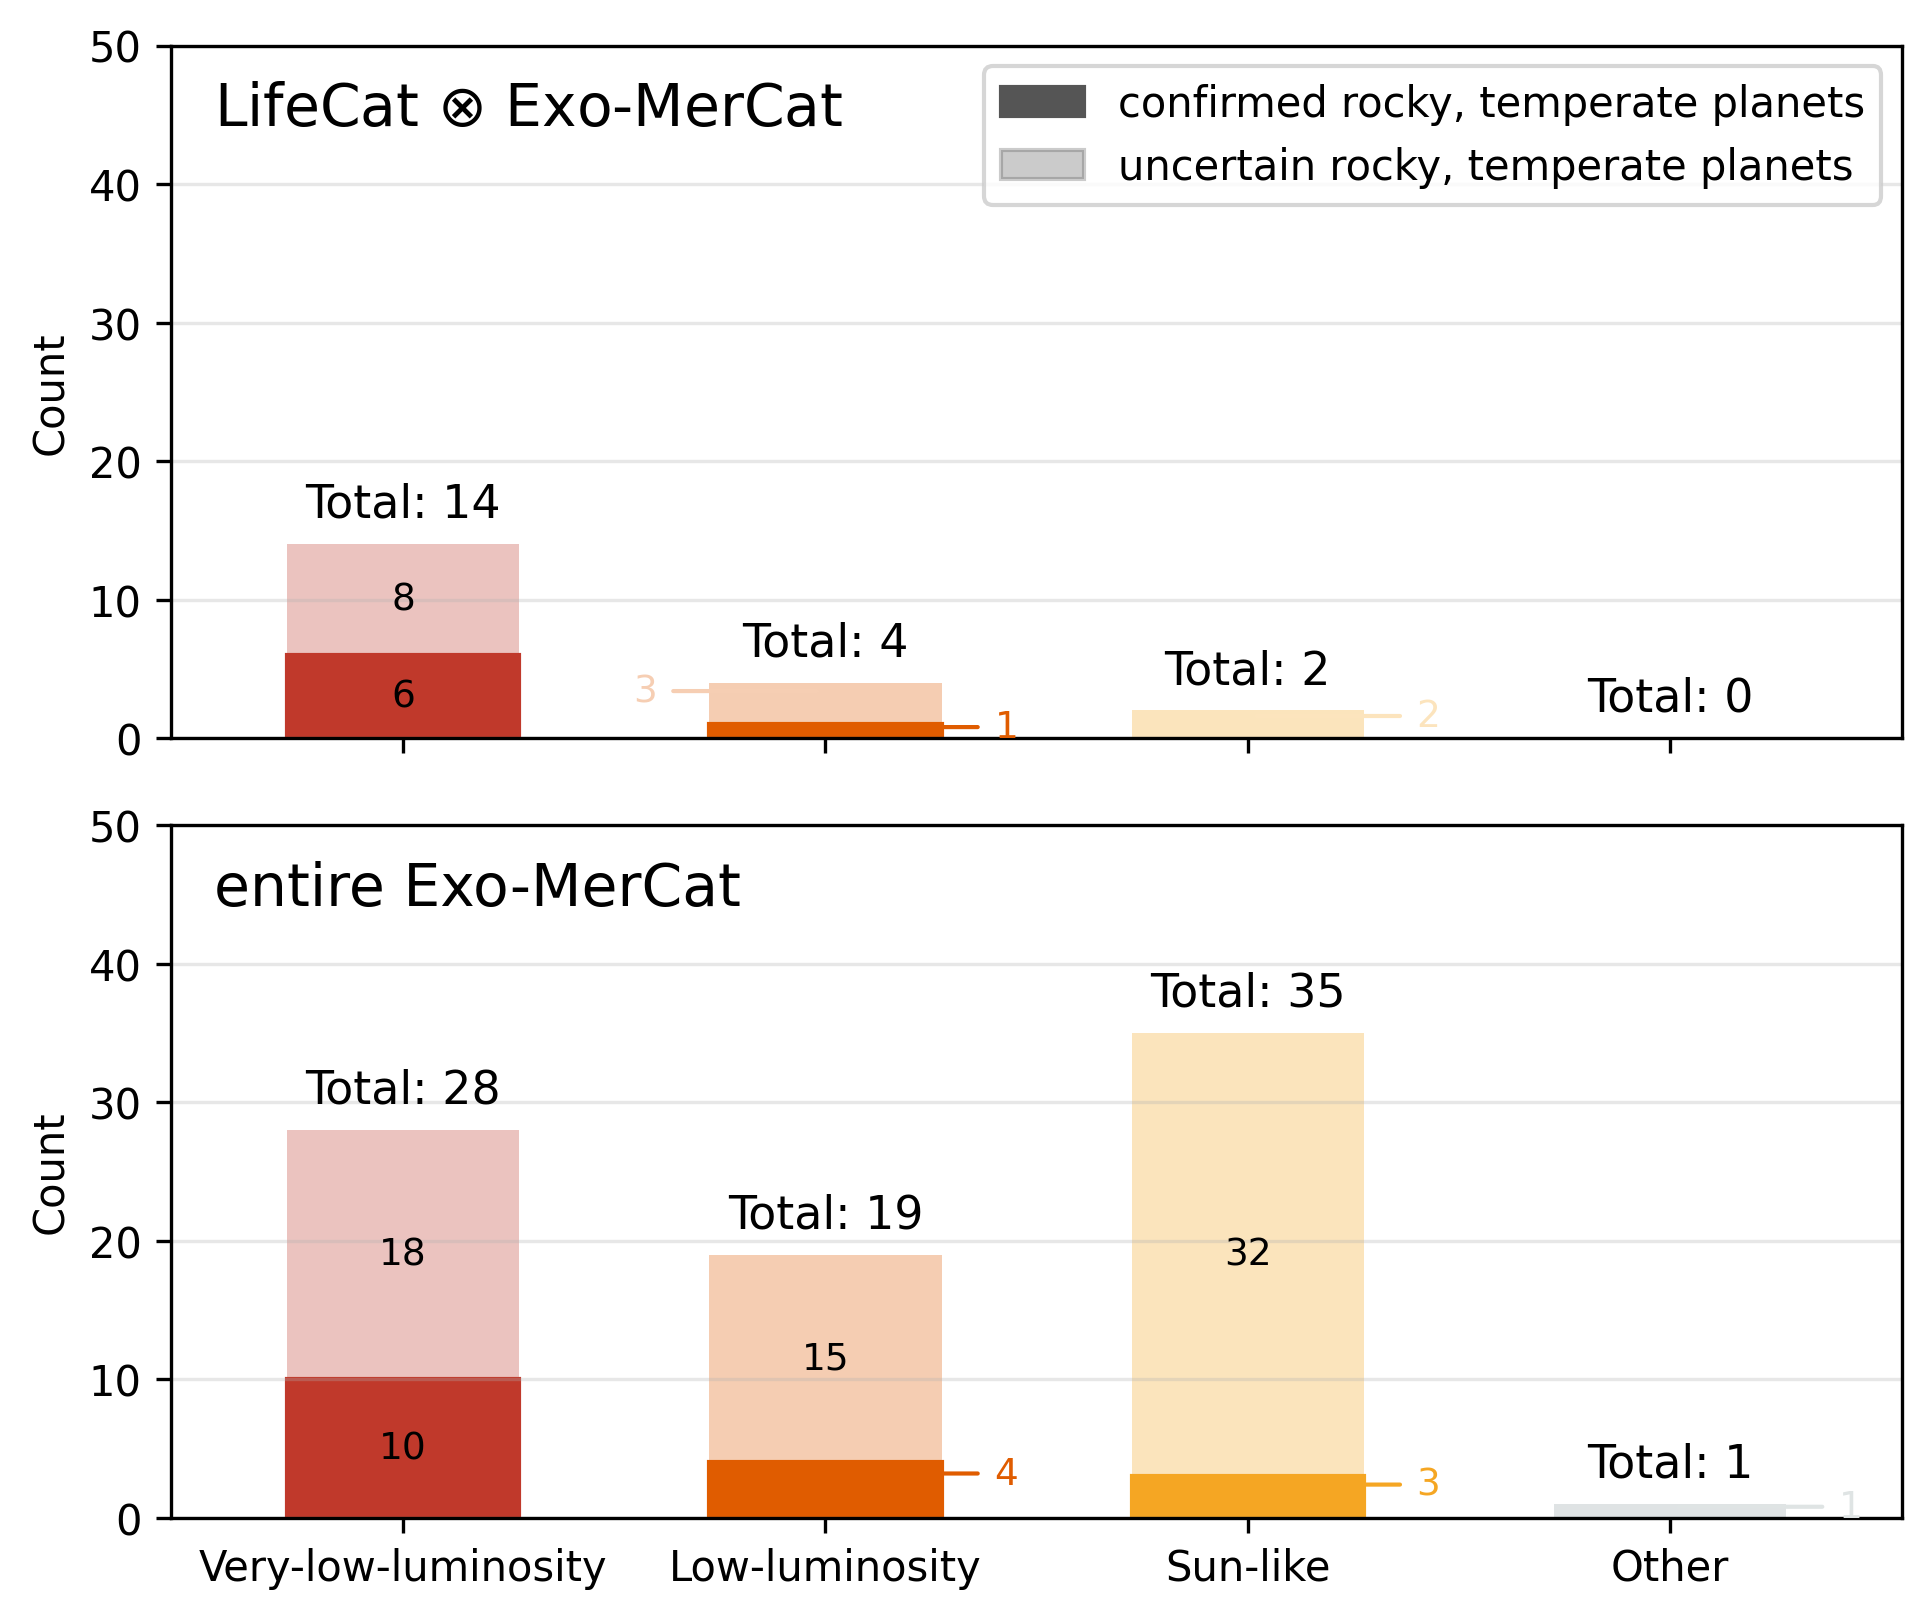

In [17]:
def plot_rocky_temp_bars(ax: plt.Axes, catalog: Table, title: str, maximum: int, width=0.55):
    x = np.arange(len(CATEGORY_ORDER))
    inside_thresh = max(0.1*maximum, 1)
    tick_offset = 0.125

    for i, cat in enumerate(CATEGORY_ORDER):
        color = CATEGORY_COLORS[cat]
        n_confirmed = sum((catalog["rocky_temp_status"] == "Confirmed") & (catalog["spectral_category"] == cat))
        n_uncertain = sum((catalog["rocky_temp_status"] == "Uncertain") & (catalog["spectral_category"] == cat))
        ax.bar(i, n_confirmed, width, color=color, alpha=0.35)
        if n_confirmed:
            ax.bar(
                x=i,
                height=n_confirmed,
                width=width,
                bottom=0,
                color=color,
                edgecolor=color
            )
        if n_uncertain:
            ax.bar(
                x=i,
                height=n_uncertain,
                width=width, 
                bottom=n_confirmed,
                alpha=0.3,
                color=color,
            )

        bar_total = n_confirmed + n_uncertain

        small_segs = []
        for seg_count, seg_bottom, transparent in [
            (n_confirmed, 0, False),
            (n_uncertain,  n_confirmed, True),
        ]:
            if seg_count == 0:
                continue
            seg_center_y = seg_bottom + seg_count / 2
            seg_high_y = seg_bottom + seg_count * 0.8
            if seg_count >= inside_thresh:
                ax.text(i, seg_center_y, str(seg_count),
                        ha='center', va='center', fontsize=9, color='black')
            else:
                small_segs.append((seg_high_y, seg_count, transparent))

        for j, (seg_center_y, seg_count, transparent) in enumerate(small_segs):
            ann_color = color if not transparent else _lighten(color,0.7)
            if j % 2 == 0:
                ax.annotate(str(seg_count),
                            xy=(i, seg_center_y),
                            xytext=(i + width/2 + tick_offset, seg_center_y),
                            fontsize=9, va='center', ha='left', color=ann_color, alpha=1 if transparent else 1,
                            arrowprops=dict(arrowstyle='-', color=ann_color, lw=1.0,  alpha=(1 if transparent else 1)))
            else:
                ax.annotate(str(seg_count),
                            xy=(i, seg_center_y),
                            xytext=(i - width/2 - tick_offset, seg_center_y),
                            fontsize=9, va='center', ha='right', color=ann_color, alpha=1 if transparent else 1,
                            arrowprops=dict(arrowstyle='-', color=ann_color, lw=1.0, alpha=(1 if transparent else 1)))
    
        ax.text(i, bar_total + maximum * 0.025, f'Total: {bar_total}',
                ha='center', va='bottom', fontsize=11)

    legend_handles = []
    legend_handles.append(Patch(color='#555555', alpha=1.0,
                            label='confirmed rocky, temperate planets'))
    legend_handles.append(Patch(color='#555555', alpha=0.3,
                                    label='uncertain rocky, temperate planets'))
    # legend_handles.append(Patch(fill=False, edgecolor='none', 
    #                             label=rf'Temperate: ${HZ_OUTER}$–${HZ_INNER}\,S_\oplus$'))
    
    ax.set_xlim(-width, len(CATEGORY_ORDER) - 1 + width)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORY_ORDER)
    ax.set_ylim(0, maximum)
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(handles=legend_handles)

fig, ax = plt.subplots(2, figsize=(6.5, 5.5), sharex=True)
plt.tight_layout()
ax[0].grid(axis='y', alpha=0.3)
ax[1].grid(axis='y', alpha=0.3)
plot_rocky_temp_bars(ax[0], e_cm_emc, "", 50)
plot_rocky_temp_bars(ax[1], e_emc, "", 50)
ax[0].text(0.025, 0.95, r'LifeCat $\otimes$ Exo-MerCat',
    horizontalalignment='left',
    verticalalignment='top',
    transform = ax[0].transAxes,
    fontsize=14, 
)
ax[1].text(0.025, 0.95, 'entire Exo-MerCat',
    horizontalalignment='left',
    verticalalignment='top',
    transform = ax[1].transAxes,
    fontsize=14, 
)   

ax[1].get_legend().remove()
# plt.grid()
plt.savefig("./notebooks/plots/rocky_temp_yield_plot.pdf", bbox_inches='tight', dpi=300)

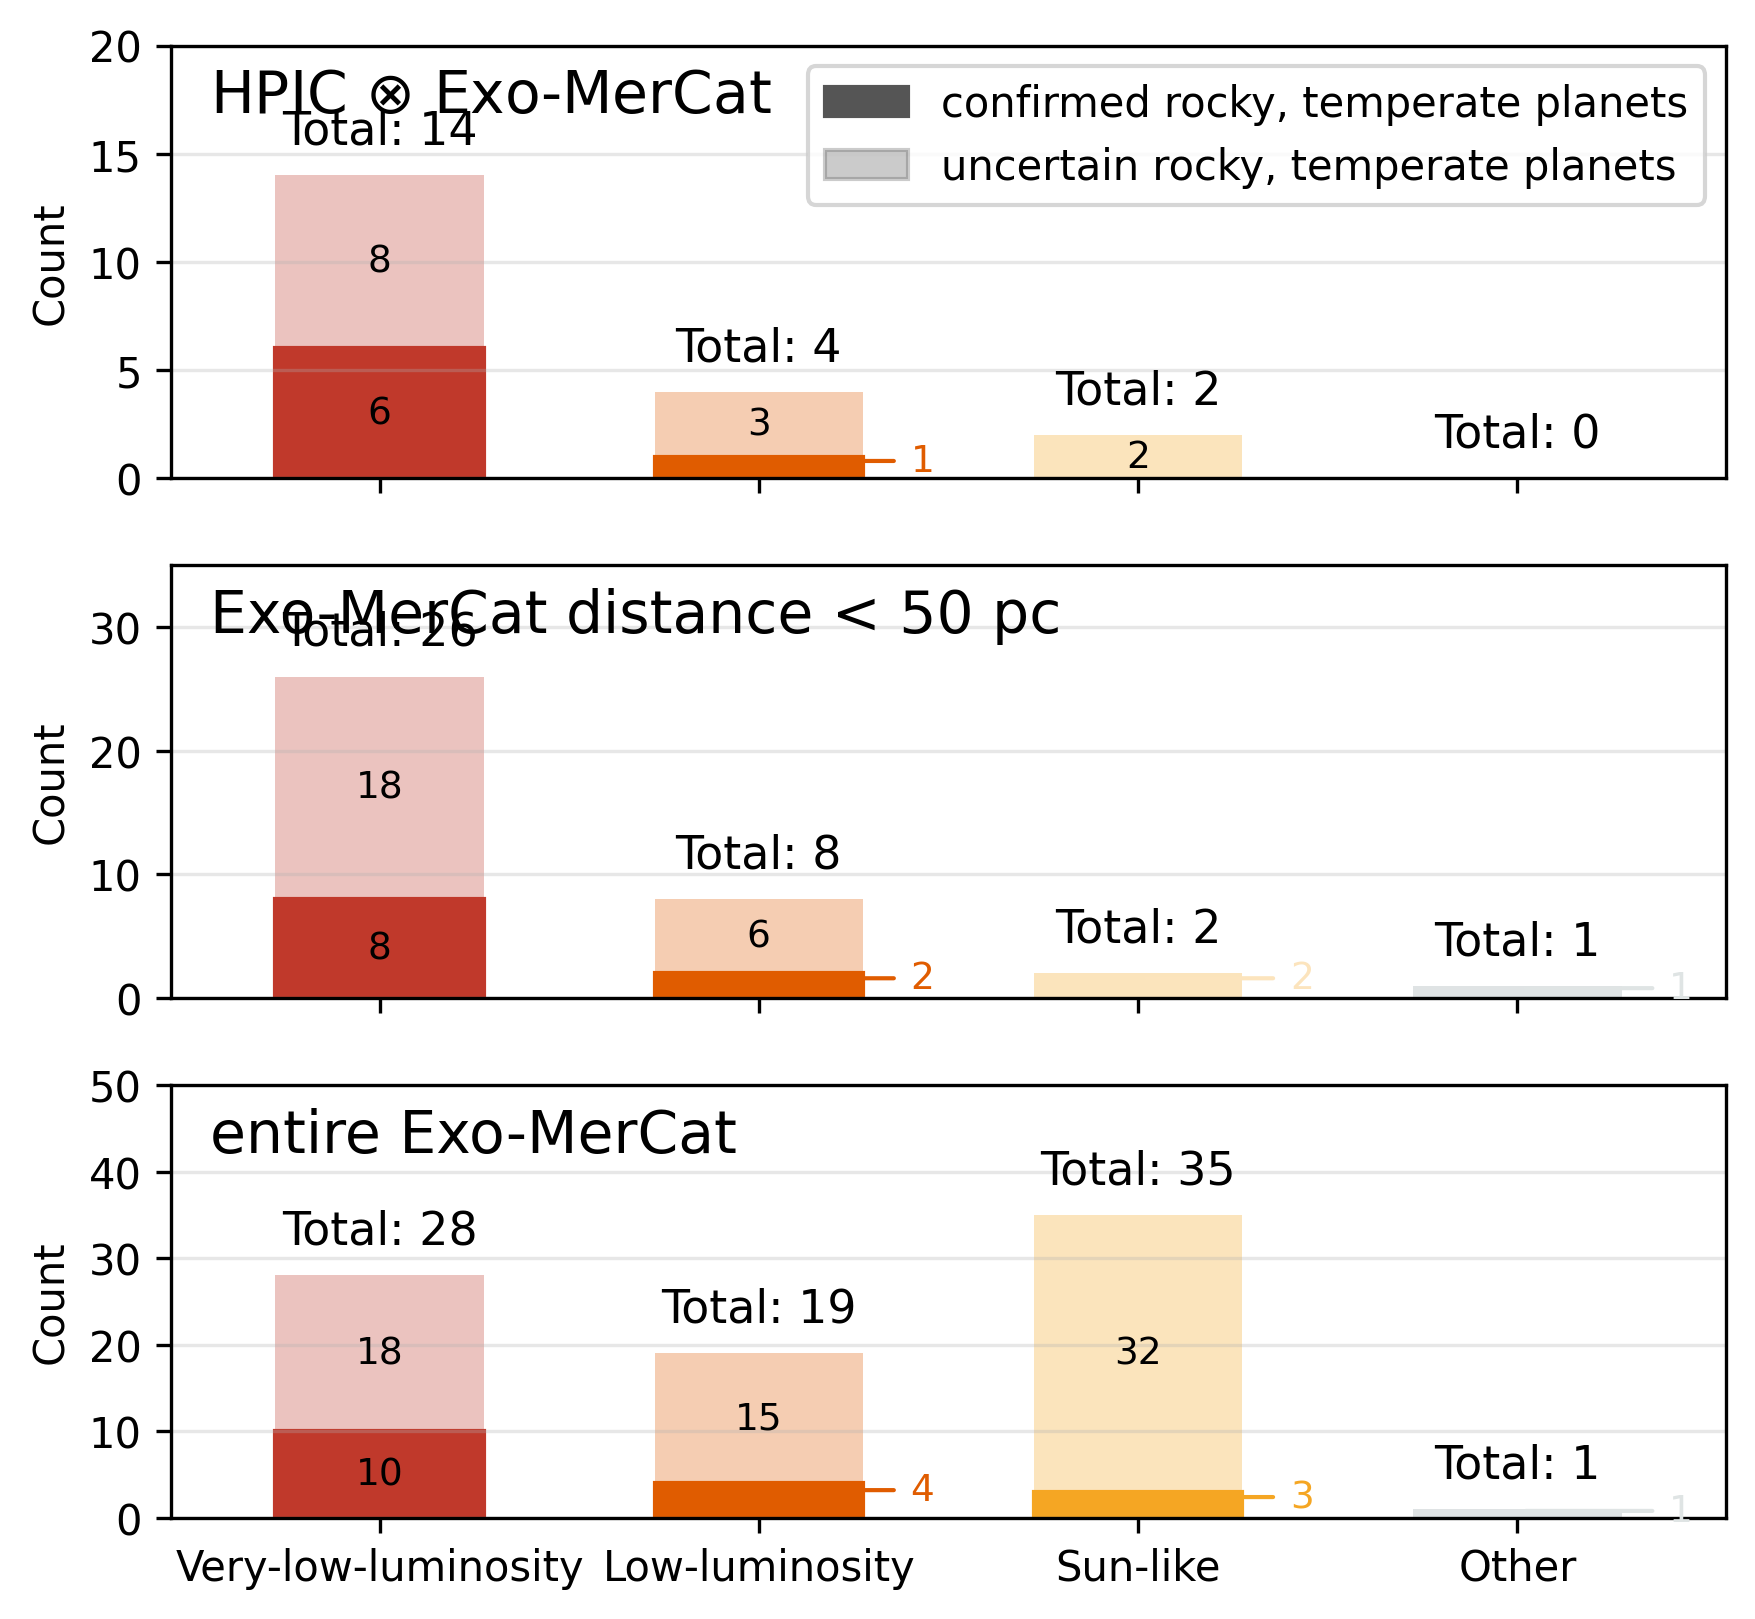

In [18]:
def plot_rocky_temp_bars(ax: plt.Axes, catalog: Table, title: str, maximum: int, width=0.55):
    x = np.arange(len(CATEGORY_ORDER))
    inside_thresh = max(0.1*maximum, 1)
    tick_offset = 0.125

    for i, cat in enumerate(CATEGORY_ORDER):
        color = CATEGORY_COLORS[cat]
        n_confirmed = sum((catalog["rocky_temp_status"] == "Confirmed") & (catalog["spectral_category"] == cat))
        n_uncertain = sum((catalog["rocky_temp_status"] == "Uncertain") & (catalog["spectral_category"] == cat))
        ax.bar(i, n_confirmed, width, color=color, alpha=0.35)
        if n_confirmed:
            ax.bar(
                x=i,
                height=n_confirmed,
                width=width,
                bottom=0,
                color=color,
                edgecolor=color
            )
        if n_uncertain:
            ax.bar(
                x=i,
                height=n_uncertain,
                width=width, 
                bottom=n_confirmed,
                alpha=0.3,
                color=color,
            )

        bar_total = n_confirmed + n_uncertain

        small_segs = []
        for seg_count, seg_bottom, transparent in [
            (n_confirmed, 0, False),
            (n_uncertain,  n_confirmed, True),
        ]:
            if seg_count == 0:
                continue
            seg_center_y = seg_bottom + seg_count / 2
            seg_center_high = seg_bottom + seg_count * 0.8
            if seg_count >= inside_thresh:
                ax.text(i, seg_center_y, str(seg_count),
                        ha='center', va='center', fontsize=9, color='black')
            else:
                small_segs.append((seg_center_high, seg_count, transparent))

        for j, (seg_center_y, seg_count, transparent) in enumerate(small_segs):
            ann_color = color if not transparent else _lighten(color,0.7)
            if j % 2 == 0:
                ax.annotate(str(seg_count),
                            xy=(i, seg_center_y),
                            xytext=(i + width/2 + tick_offset, seg_center_y),
                            fontsize=9, va='center', ha='left', color=ann_color, alpha=1 if transparent else 1,
                            arrowprops=dict(arrowstyle='-', color=ann_color, lw=1.0,  alpha=(1 if transparent else 1)))
            else:
                ax.annotate(str(seg_count),
                            xy=(i, seg_center_y),
                            xytext=(i - width/2 - tick_offset, seg_center_y),
                            fontsize=9, va='center', ha='right', color=ann_color, alpha=1 if transparent else 1,
                            arrowprops=dict(arrowstyle='-', color=ann_color, lw=1.0, alpha=(1 if transparent else 1)))
    
        ax.text(i, bar_total + maximum * 0.05, f'Total: {bar_total}',
                ha='center', va='bottom', fontsize=11)

    legend_handles = []
    legend_handles.append(Patch(color='#555555', alpha=1.0,
                            label='confirmed rocky, temperate planets'))
    legend_handles.append(Patch(color='#555555', alpha=0.3,
                                    label='uncertain rocky, temperate planets'))
    # legend_handles.append(Patch(fill=False, edgecolor='none', 
    #                             label=rf'Temperate: ${HZ_OUTER}$–${HZ_INNER}\,S_\oplus$'))
    
    ax.set_xlim(-width, len(CATEGORY_ORDER) - 1 + width)
    ax.set_xticks(x)
    ax.set_xticklabels(CATEGORY_ORDER)
    ax.set_ylim(0, maximum)
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend(handles=legend_handles)
    
fig, ax = plt.subplots(3, figsize=(6, 5.5), sharex=True)
plt.tight_layout()
ax[0].grid(axis='y', alpha=0.3)
ax[1].grid(axis='y', alpha=0.3)
ax[2].grid(axis='y', alpha=0.3)
plot_rocky_temp_bars(ax[0], e_cm_emc, "", 20)
plot_rocky_temp_bars(ax[1], e_emc[e_emc['sy_dist'] - e_emc['sy_dist_min'] < 50], "", 35)
plot_rocky_temp_bars(ax[2], e_emc, "", 50)
ax[0].text(0.025, 0.95, r'HPIC $\otimes$ Exo-MerCat',
    horizontalalignment='left',
    verticalalignment='top',
    transform = ax[0].transAxes,
    fontsize=14, 
)
ax[1].text(0.025, 0.95, r'Exo-MerCat distance < 50 pc',
    horizontalalignment='left',
    verticalalignment='top',
    transform = ax[1].transAxes,
    fontsize=14, 
)
ax[2].text(0.025, 0.95, 'entire Exo-MerCat',
    horizontalalignment='left',
    verticalalignment='top',
    transform = ax[2].transAxes,
    fontsize=14, 
)   

ax[1].get_legend().remove()
ax[2].get_legend().remove()

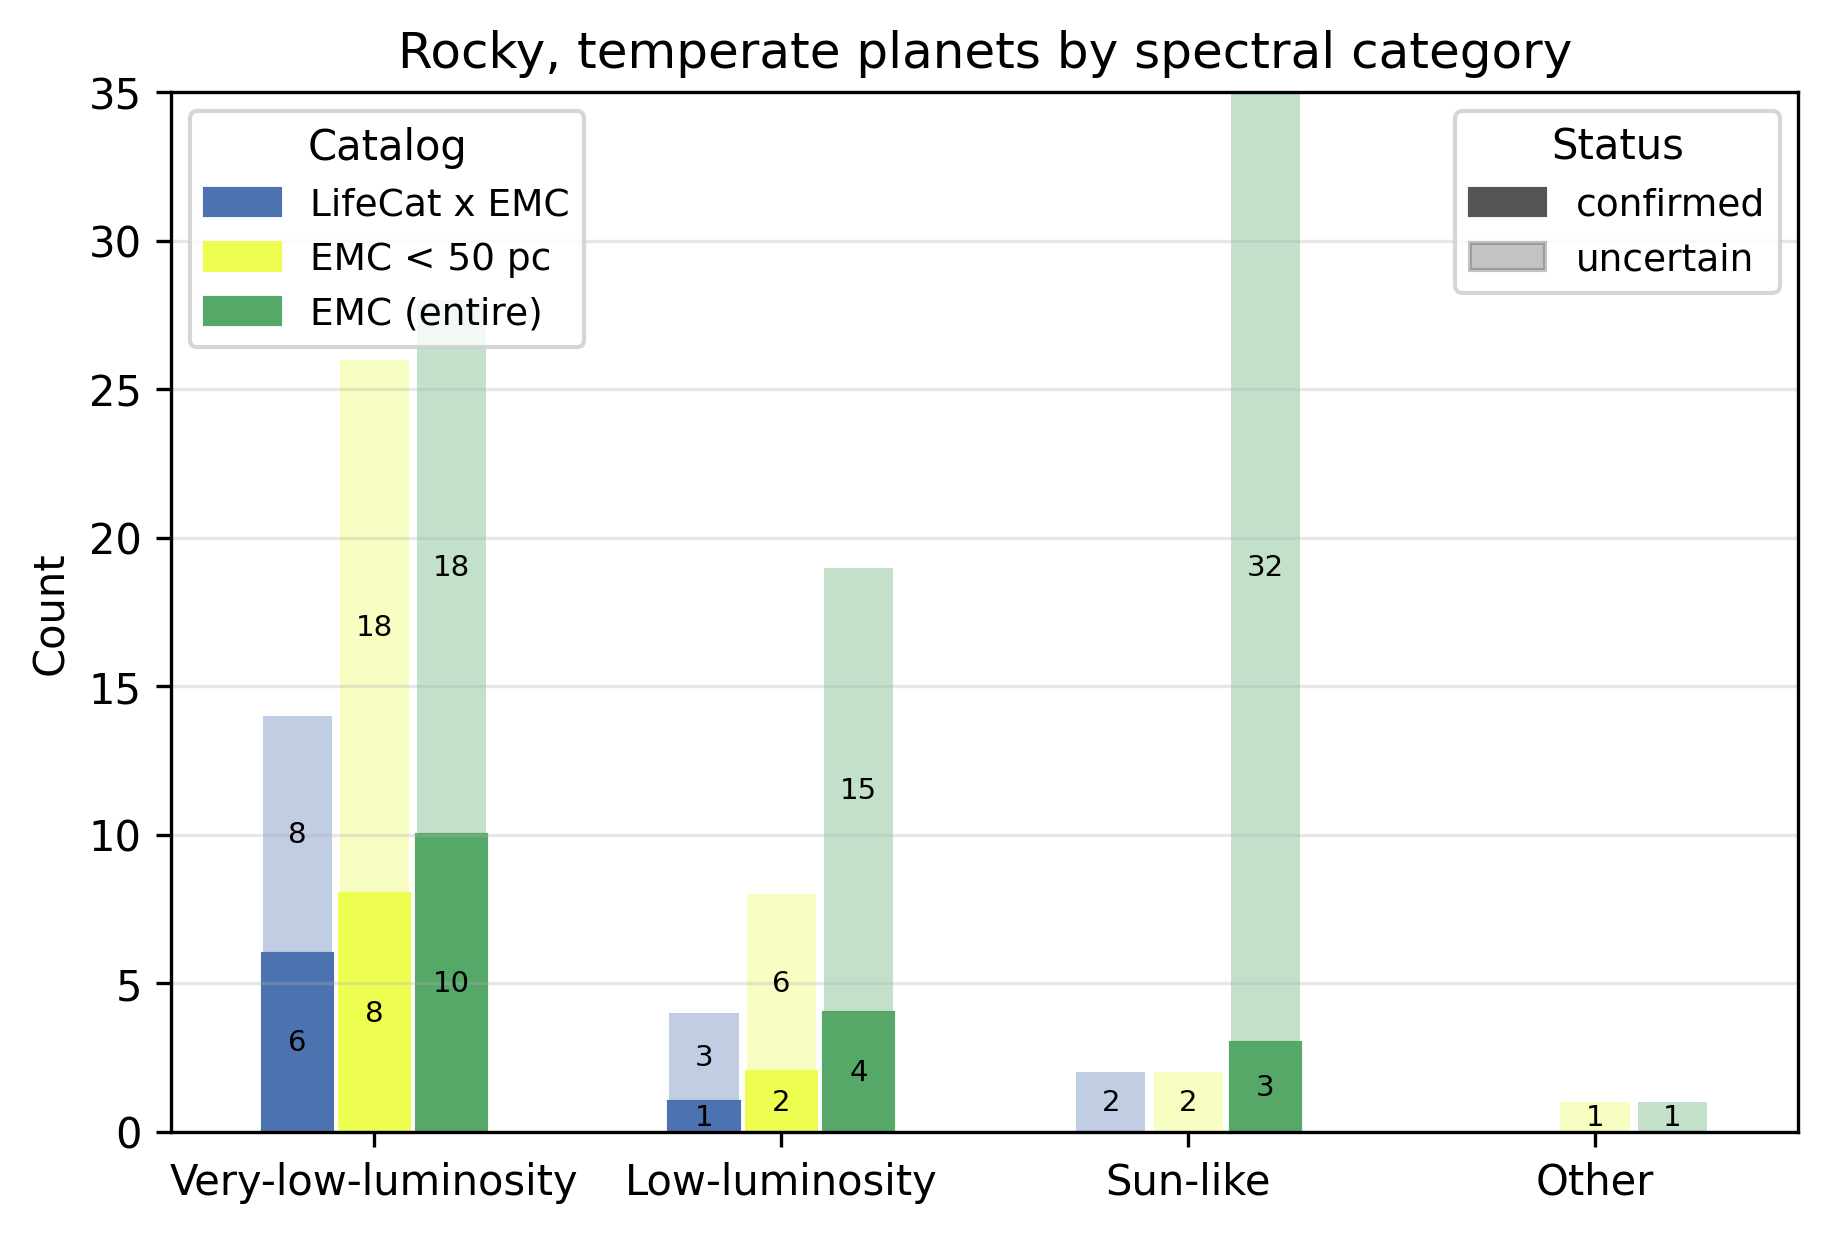

In [19]:
CATALOG_STYLES = {
    'LifeCat x EMC':        '#4C72B0',
    'EMC < 50 pc':       "#edfe50",
    'EMC (entire)':      '#55A868',
}

def plot_rocky_temp_bars(ax: plt.Axes, catalog: Table, maximum: int, color: str,
                          width=0.17, x_offset=0.0):
    x = np.arange(len(CATEGORY_ORDER)) + x_offset
    inside_thresh = 1
    tick_offset = 0.09

    for i, cat in enumerate(CATEGORY_ORDER):
        xi = x[i]
        n_confirmed = sum((catalog["rocky_temp_status"] == "Confirmed") & (catalog["spectral_category"] == cat))
        n_uncertain = sum((catalog["rocky_temp_status"] == "Uncertain") & (catalog["spectral_category"] == cat))

        if n_confirmed:
            ax.bar(x=xi, height=n_confirmed, width=width, bottom=0,
                   color=color, edgecolor=color)
        if n_uncertain:
            ax.bar(x=xi, height=n_uncertain, width=width, bottom=n_confirmed,
                   alpha=0.35, color=color)

        bar_total = n_confirmed + n_uncertain

        small_segs = []
        for seg_count, seg_bottom, transparent in [
            (n_confirmed, 0, False),
            (n_uncertain, n_confirmed, True),
        ]:
            if seg_count == 0:
                continue
            seg_center_y = seg_bottom + seg_count / 2
            if seg_count >= inside_thresh:
                ax.text(xi, seg_center_y, str(seg_count),
                        ha='center', va='center', fontsize=7, color='black')
            else:
                small_segs.append((seg_center_y, seg_count, transparent))

        for j, (seg_center_y, seg_count, transparent) in enumerate(small_segs):
            ann_color = color if not transparent else _lighten(color, 0.6)
            side = 1 if j % 2 == 0 else -1
            ax.annotate(str(seg_count),
                        xy=(xi, seg_center_y),
                        xytext=(xi + side*(width/2 + tick_offset), seg_center_y),
                        fontsize=7, va='center',
                        ha='left' if side > 0 else 'right',
                        color=ann_color,
                        arrowprops=dict(arrowstyle='-', color=ann_color, lw=0.8))

        # if bar_total:
        # ax.text(xi, bar_total + maximum * 0.03, str(bar_total),
        #         ha='center', va='bottom', fontsize=7, color=color)

    ax.set_xticks(np.arange(len(CATEGORY_ORDER)))
    ax.set_xticklabels(CATEGORY_ORDER)
    ax.set_ylim(0, maximum)
    ax.set_ylabel('Count')


fig, ax = plt.subplots(1, figsize=(7, 4.5))
ax.grid(axis='y', alpha=0.3)

maximum = 35
group_width = 0.17
gap = 0.02
offsets = [-(group_width + gap), 0, (group_width + gap)]

plot_rocky_temp_bars(ax, e_cm_emc, maximum, CATALOG_STYLES['LifeCat x EMC'],
                     width=group_width, x_offset=offsets[0])
plot_rocky_temp_bars(ax, e_emc[e_emc['sy_dist'] - e_emc['sy_dist_min'] < 50], maximum,
                     CATALOG_STYLES['EMC < 50 pc'], width=group_width, x_offset=offsets[1])
plot_rocky_temp_bars(ax, e_emc, maximum, CATALOG_STYLES['EMC (entire)'],
                     width=group_width, x_offset=offsets[2])

ax.set_xlim(-0.5, len(CATEGORY_ORDER) - 0.5)
ax.set_title('Rocky, temperate planets by spectral category')

# --- combined legend: catalog identity (color) + status (shading) ---
catalog_handles = [Patch(color=c, label=name) for name, c in CATALOG_STYLES.items()]
status_handles = [
    Patch(color='#555555', alpha=1.0, label='confirmed'),
    Patch(color='#555555', alpha=0.35, label='uncertain'),
    # Patch(fill=False, edgecolor='none', label=rf'Temperate: ${HZ_OUTER}$–${HZ_INNER}\,S_\oplus$'),
]
legend1 = ax.legend(handles=catalog_handles, title='Catalog', loc='upper left', fontsize=9)
ax.add_artist(legend1)
ax.legend(handles=status_handles, title='Status', loc='upper right', fontsize=9)

In [20]:
emc_d50 = e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] < 50]
emc_d50_nonhpic = emc_d50[~np.isin(emc_d50["exo-mercat_name"], e_cm_emc["exo-mercat_name"])]
(emc_d50_nonhpic["spectral_category"] != 'Other').sum()

np.int64(348)

In [21]:
cols = ['rocky_temp_status', 'status', 'is_rocky', 'is_temperate', 'spectral_category','exo-mercat_name', 'host','st_spectype',  'pl_insol', 'pl_insol_max', 'pl_insol_min', 'r_earth', 'r_earth_max', 'r_earth_min', 'r_lower_bound', 'r_upper_bound', 'pl_eqt', 'pl_eqt_max', 'pl_eqt_min', 'a', 'sy_dist', 'sy_vmag', 'star_name', 'mass_earth', ]
emc_cols = cols.copy()
emc_cols.remove("star_name")
emc_cols.append("nasa_name")
new_crtps = emc_d50_nonhpic[emc_d50_nonhpic["rocky_temp_status"] != '']
new_crtps.sort(["rocky_temp_status", "spectral_category"])
new_crtps[emc_cols].show_in_notebook(autofit_columns=True)

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

In [22]:
new_crtps["rocky_temp_status", "status", "exo-mercat_name", "spectral_category"].pprint_all()

rocky_temp_status     status          exo-mercat_name        spectral_category 
----------------- ------------- --------------------------- -------------------
        Confirmed     CONFIRMED                   TOI-700 d      Low-luminosity
        Confirmed     CONFIRMED                   TOI-700 e      Low-luminosity
        Confirmed     CONFIRMED                 LP  890-9 c Very-low-luminosity
        Uncertain     CANDIDATE             LP  425-186 .01      Low-luminosity
        Uncertain     CONFIRMED           LSPM J1902+7525 c      Low-luminosity
        Uncertain     CONFIRMED            PM J13119+6550 d      Low-luminosity
        Uncertain     CANDIDATE                LP  873-20 b               Other
        Uncertain     CANDIDATE 2MASS J05021345+1442367 .01 Very-low-luminosity
        Uncertain     CANDIDATE 2MASS J05021345+1442367 .02 Very-low-luminosity
        Uncertain CONTROVERSIAL 2MASS J06034353-8127303 .01 Very-low-luminosity
        Uncertain     CONFIRMED         

In [23]:
catalog = e_cm_emc
catalog.sort("rocky_temp_status")
catalog[cols][(catalog["rocky_temp_status"] != '') ].show_in_notebook(auto_fit_columns=True)

DataGrid(auto_fit_columns=True, auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_render…

```

rocky&temperate status publication status exo-mercat name          host star spectral_category 
---------------------- ------------------ ----------------------- ----------------------------
    Confirmed                CONFIRMED                    K2-3 d                Low-luminosity
    Confirmed                CONFIRMED               L  372-58 d           Very-low-luminosity
    Confirmed                CONFIRMED               L  372-58 c           Very-low-luminosity
    Confirmed                CONFIRMED                 G  32-5 b           Very-low-luminosity
    Confirmed                CONFIRMED              TRAPPIST-1 f           Very-low-luminosity
    Confirmed                CONFIRMED              TRAPPIST-1 e           Very-low-luminosity
    Confirmed                CONFIRMED              TRAPPIST-1 d           Very-low-luminosity
    Uncertain            CONTROVERSIAL             HD 156384 C f                Low-luminosity
    Uncertain            CONTROVERSIAL             HD 156384 C e                Low-luminosity
    Uncertain                CANDIDATE               MCC 189 .01                Low-luminosity
    Uncertain                CONFIRMED               HD 137010 b                      Sun-like
    Uncertain                CANDIDATE             HD   6660 .01                      Sun-like
    Uncertain                CONFIRMED               Ross  128 b           Very-low-luminosity
    Uncertain                CONFIRMED           BD-17   588 A d           Very-low-luminosity
    Uncertain                CONFIRMED                G 158-27 b           Very-low-luminosity
    Uncertain                CONFIRMED                 G 261-6 b           Very-low-luminosity
    Uncertain                CONFIRMED               Wolf 1069 b           Very-low-luminosity
    Uncertain                CONFIRMED   NAME Proxima Centauri b           Very-low-luminosity
    Uncertain                CANDIDATE           CD-34  1169 .01           Very-low-luminosity
    
    Confirmed                CONFIRMED                   LP  890-9 c       Very-low-luminosity
    Confirmed                CONFIRMED                     TOI-700 d            Low-luminosity
    Confirmed                CONFIRMED                     TOI-700 e            Low-luminosity
    Uncertain            CONTROVERSIAL   2MASS J06034353-8127303 .01       Very-low-luminosity
    Uncertain                CONFIRMED                    G 125-49 b       Very-low-luminosity
    Uncertain                CANDIDATE                  LP  873-20 b                     Other
    Uncertain                CONFIRMED             LSPM J1902+7525 c            Low-luminosity
    Uncertain                CANDIDATE           LSPM J1957+5658 .01       Very-low-luminosity
    Uncertain                CONFIRMED       NAME Teegarden's Star b       Very-low-luminosity
    Uncertain                CONFIRMED       NAME Teegarden's Star c       Very-low-luminosity
    Uncertain                CONFIRMED              PM J13119+6550 d            Low-luminosity
    Uncertain                CONFIRMED                  TOI-4336 .01       Very-low-luminosity
    Uncertain                CONFIRMED                     TOI-715 b       Very-low-luminosity



```


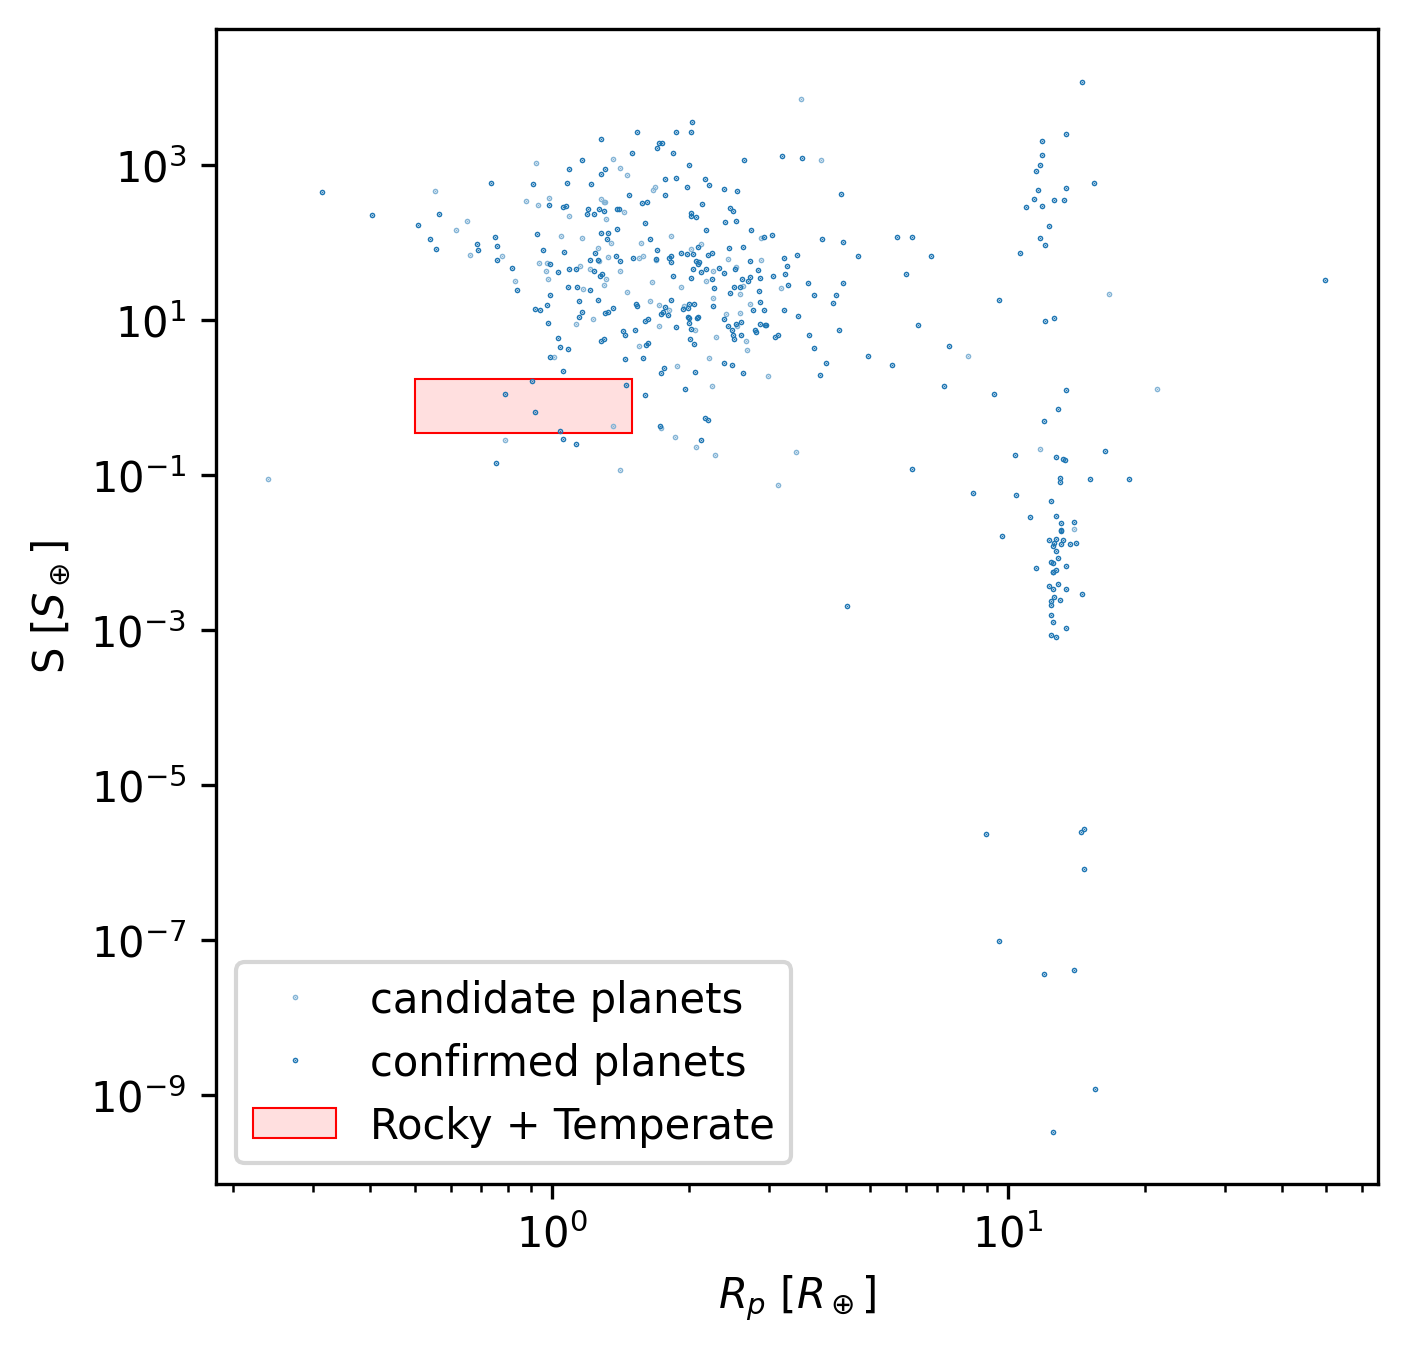

In [24]:
def plot_distr(catalog, ax, color="#1f77b4"):
    confirmed = catalog["status"] == "CONFIRMED"
    ms = 0.7
    plt.loglog(catalog['r_earth'][~confirmed], catalog['pl_insol'][~confirmed], '.', ms=ms, color=_lighten(color), label="candidate planets")
    plt.loglog(catalog['r_earth'][confirmed], catalog['pl_insol'][confirmed], '.', ms=ms, color=color, label="confirmed planets")

    plt.xlabel(r'$R_p$ $[R_\oplus]$')
    plt.ylabel(r'S [$S_\oplus$]')
    rect = Rectangle((0.5,HZ_OUTER ), 1, HZ_INNER - HZ_OUTER, 
                linewidth=.5, edgecolor='r', facecolor='#FF000020')
    rect.set_label('Rocky + Temperate')
    ax.add_patch(rect)
    ax.legend()

fig, ax = plt.subplots(figsize=(5,5))
# plot_distr(e_emc, ax)
plot_distr(e_cm_emc, ax)
ax.legend()

# plot_distr(e_cm_emc, ax, color="#ff7f0e")

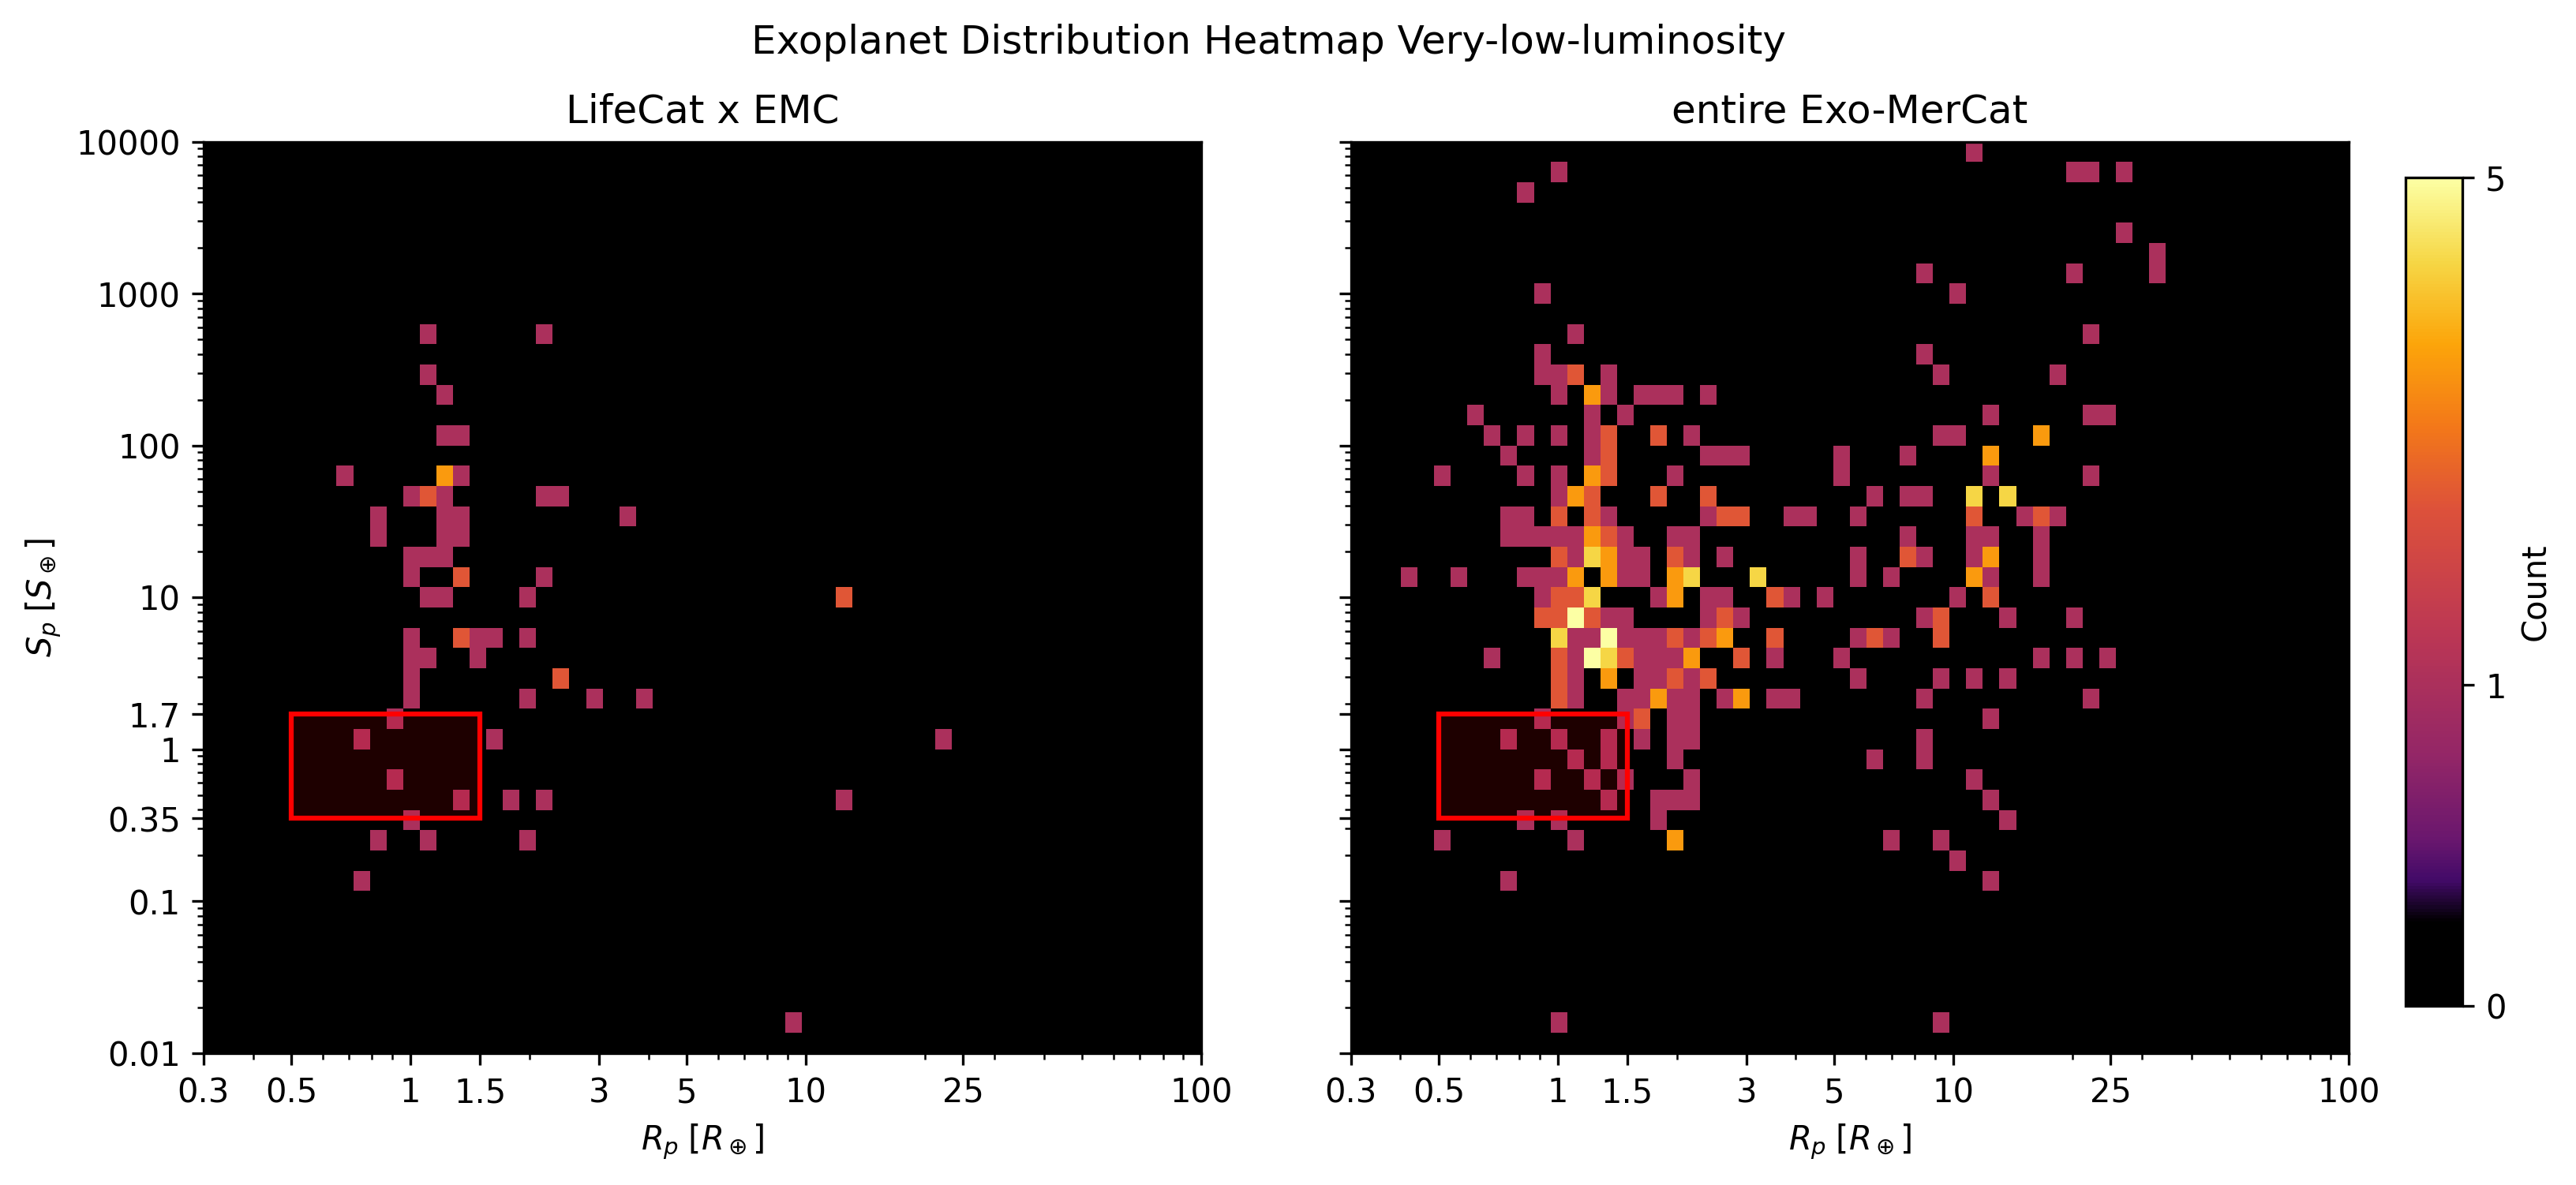

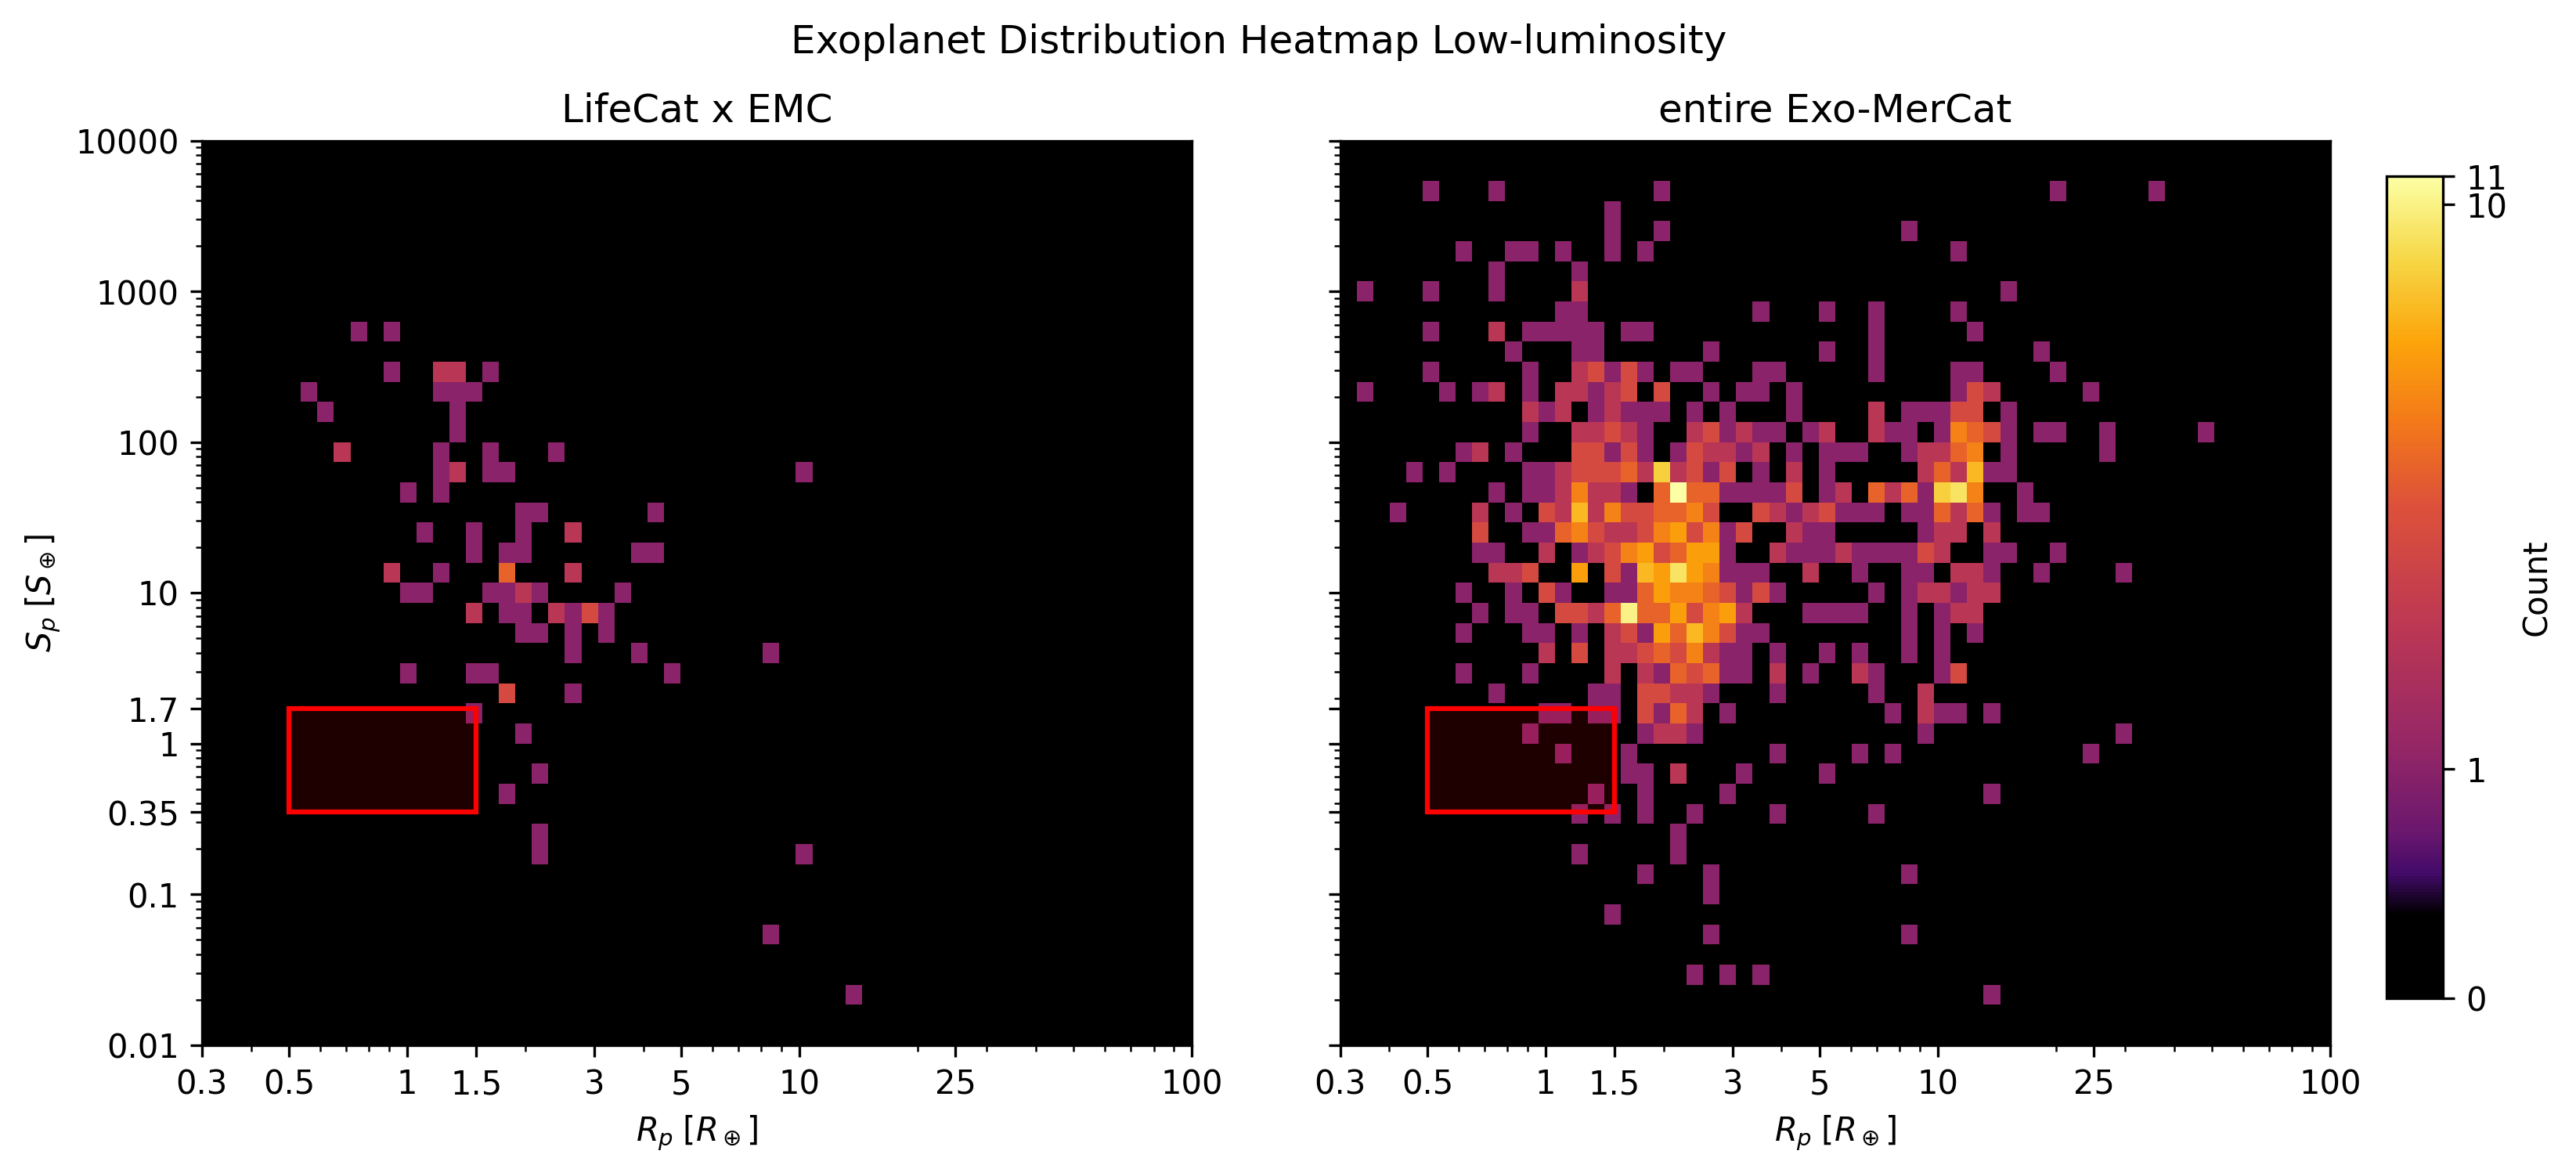

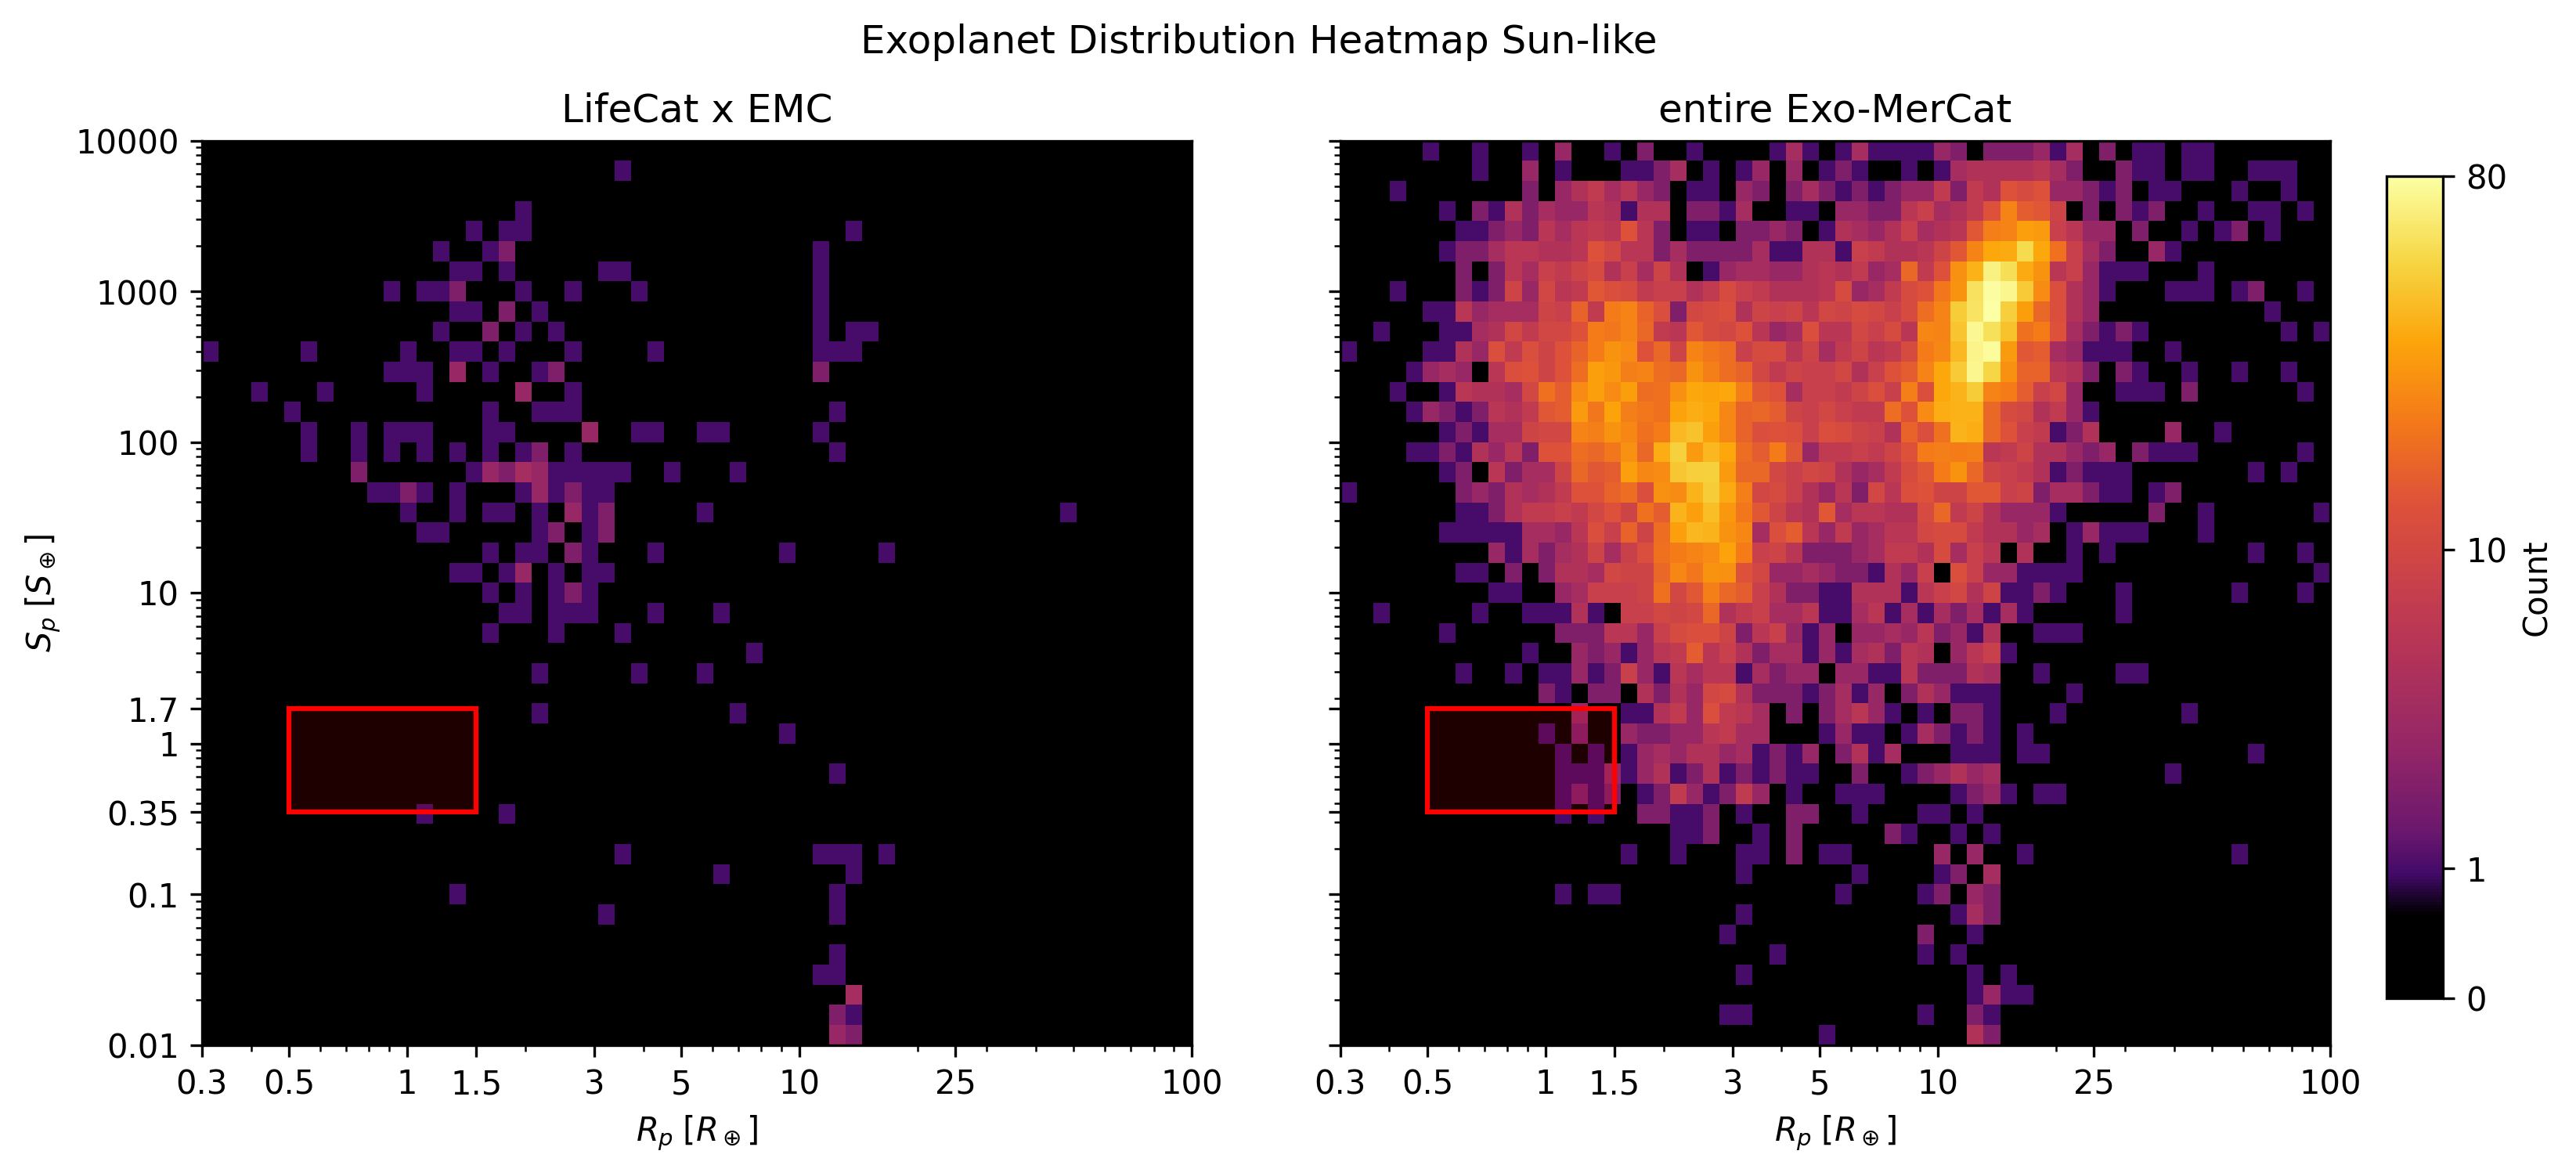

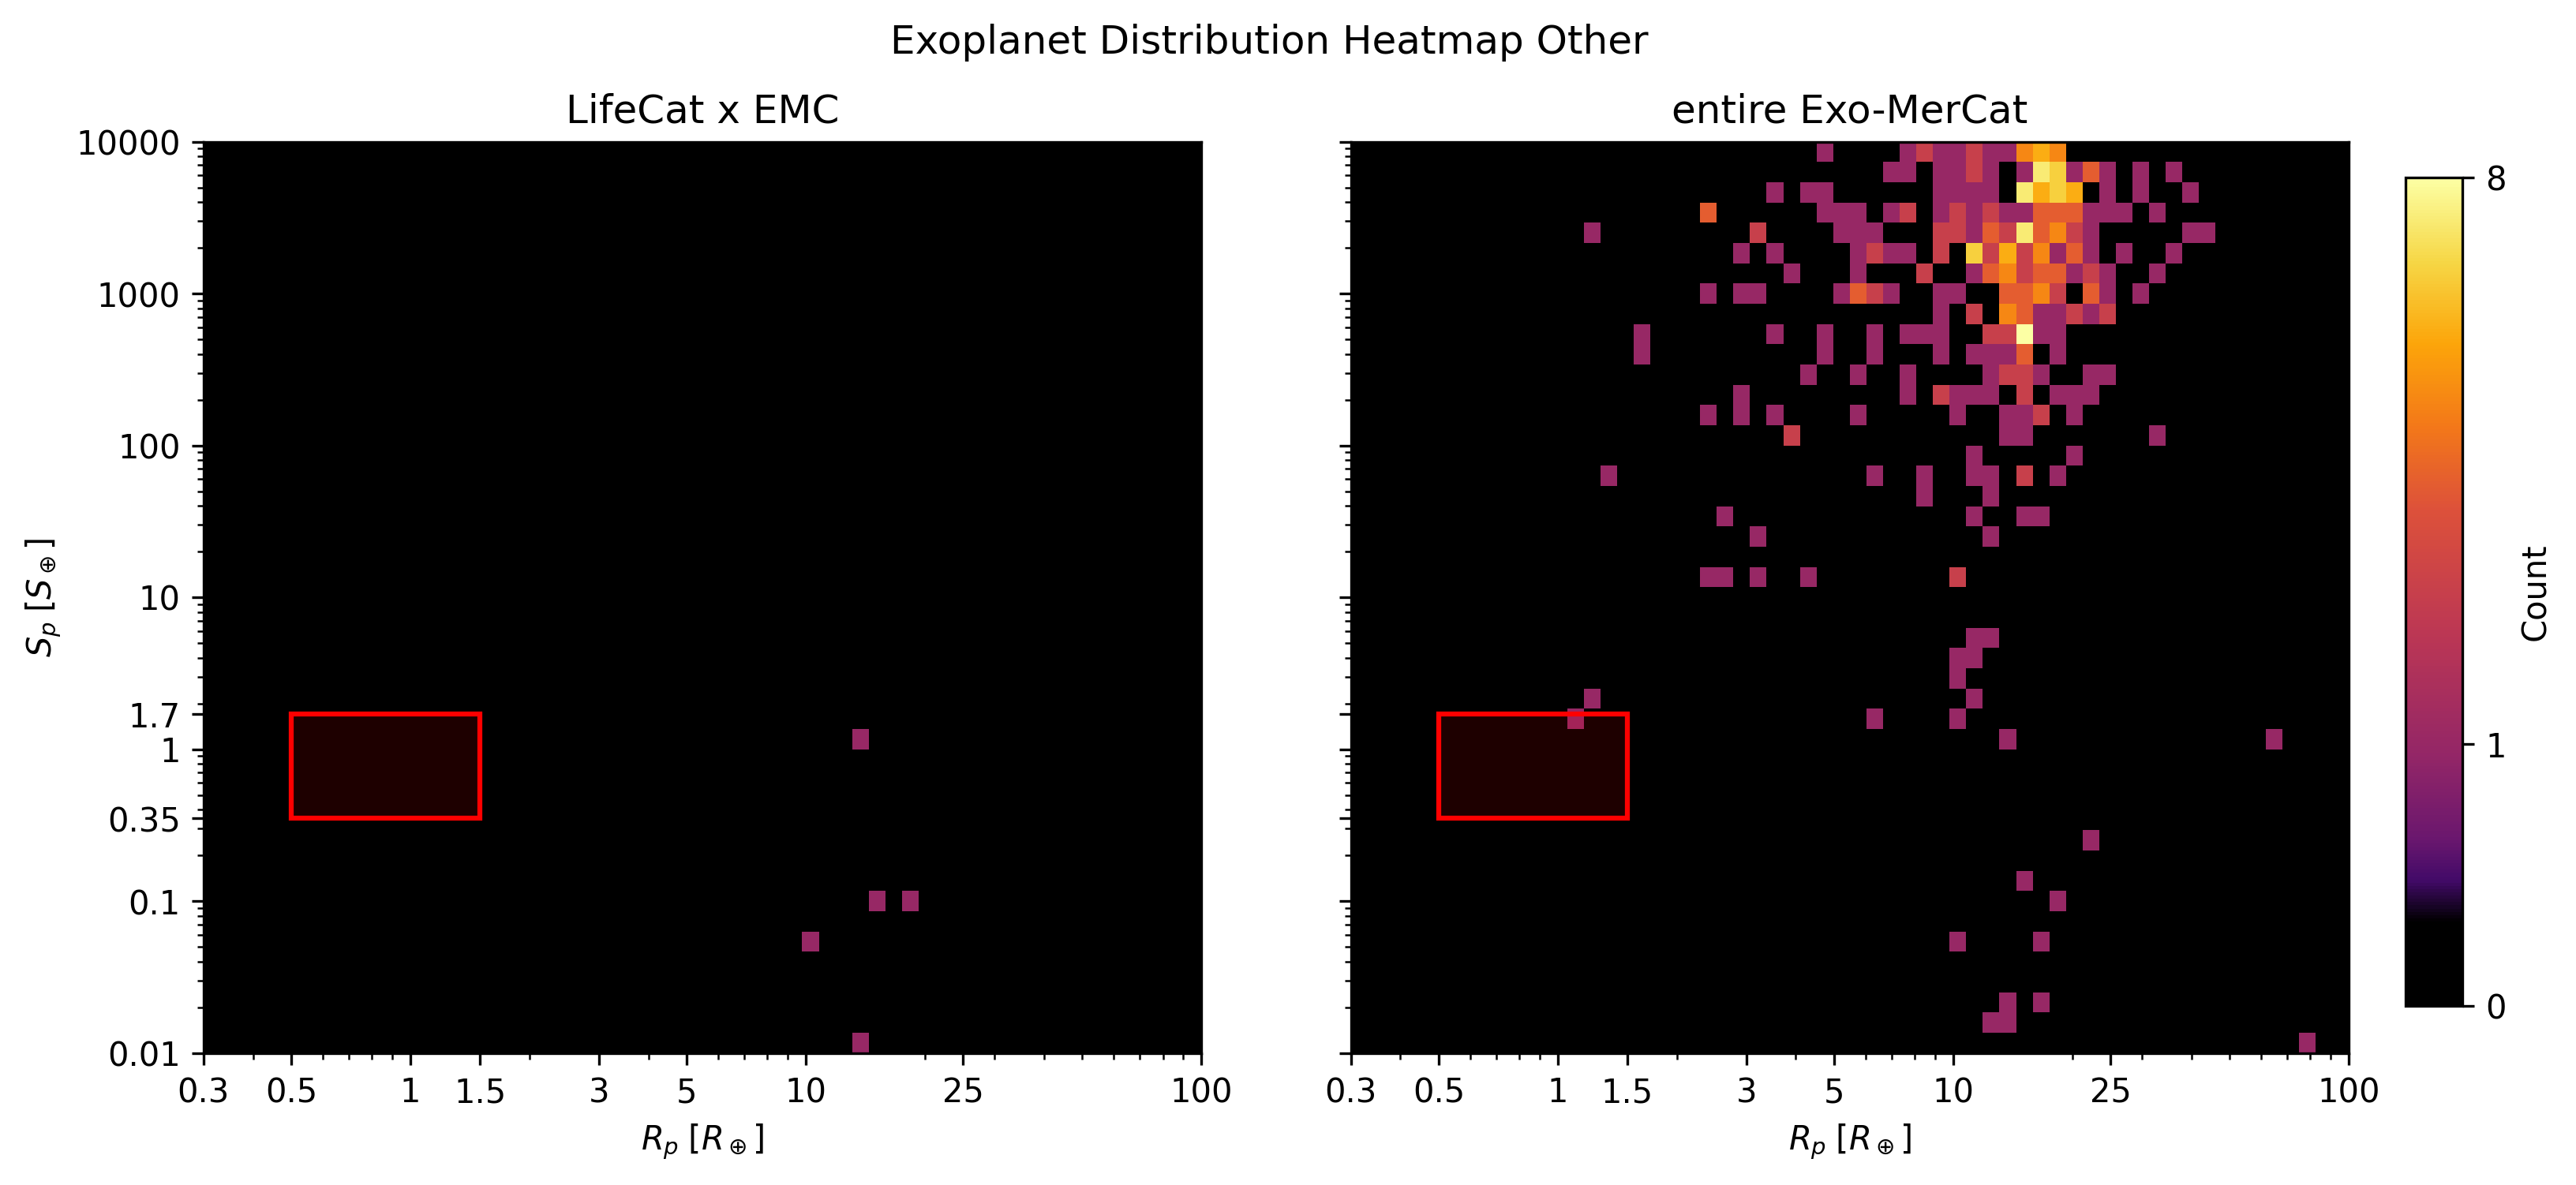

In [25]:
for c in CATEGORY_ORDER:
    double_hist_heatmap(
        e_cm_emc[e_cm_emc['spectral_category'] == c],
        e_emc[e_emc['spectral_category'] == c],
        catalog1_name="LifeCat x EMC", 
        catalog2_name="entire Exo-MerCat", 
        title="Exoplanet Distribution Heatmap "+c
    )

In [26]:
def compute_is_rocky_temperate(catalog):
    catalog['mass_earth'] = catalog['mass'] * u.M_jupiter.to(u.M_earth)
    catalog['msini_earth'] = catalog['msini'] * u.M_jupiter.to(u.M_earth)
    catalog['r_earth'] = catalog['r'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_max'] = catalog['r_max'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_min'] = catalog['r_min'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_lower_bound'] = catalog['r_lower_bound'] * u.R_jupiter.to(u.R_earth)
    catalog['r_earth_upper_bound'] = catalog['r_upper_bound'] * u.R_jupiter.to(u.R_earth)

    rocky_confirmed = rocky_mask(
        catalog['r_earth'], catalog['r_earth_min'], catalog['r_earth_max'], catalog['r_earth_lower_bound'], catalog['r_earth_upper_bound'],
        use_interval=False
    )
    rocky_uncertain = rocky_mask(
        catalog['r_earth'], catalog['r_earth_min'], catalog['r_earth_max'], catalog['r_earth_lower_bound'], catalog['r_earth_upper_bound'],
        use_interval=True
    )
    catalog['is_rocky'] = Column([''] * len(catalog), dtype="U10")
    catalog['is_rocky'][rocky_uncertain] = ['Uncertain'] * sum(rocky_uncertain)
    catalog['is_rocky'][rocky_confirmed] = ['Confirmed'] * sum(rocky_confirmed)


    temperate_confirmed = temperate_mask(
        catalog['pl_insol'], catalog['pl_insol_max'], catalog['pl_insol_min'],
        HZ_OUTER, HZ_INNER,
        use_interval=False
    )
    temperate_uncertain = temperate_mask(
        catalog['pl_insol'], catalog['pl_insol_max'], catalog['pl_insol_min'],
        HZ_OUTER, HZ_INNER,
        use_interval=True
    )
    catalog['is_temperate'] = Column([''] * len(catalog), dtype="U10")
    catalog['is_temperate'][temperate_uncertain] = ['Uncertain'] * sum(temperate_uncertain)
    catalog['is_temperate'][temperate_confirmed] = ['Confirmed'] * sum(temperate_confirmed)

    emc_confirmed = catalog["status"] == "CONFIRMED"
    rocky_temp_uncertain = temperate_uncertain & rocky_uncertain 
    rocky_temp_confirmed = temperate_confirmed & rocky_confirmed & emc_confirmed
    catalog['rocky_temp_status'] = Column([''] * len(catalog), dtype="U10")
    catalog['rocky_temp_status'][rocky_temp_uncertain] = ["Uncertain"] * sum(rocky_temp_uncertain)
    catalog['rocky_temp_status'][rocky_temp_confirmed] = ["Confirmed"] * sum(rocky_temp_confirmed)


compute_is_rocky_temperate(e_cm_emc)
compute_is_rocky_temperate(e_emc)

print("Total Number of Rocky and Temperate Planets")
print("\t Crossmatched \t    all EMC")
print(f"Confirmed:\t{sum(e_cm_emc['rocky_temp_status'] == 'Confirmed')}\t\t{sum(e_emc['rocky_temp_status'] == 'Confirmed')}" ) 
print(f"Uncertain:\t{sum(e_cm_emc['rocky_temp_status'] == 'Uncertain')}\t\t{sum(e_emc['rocky_temp_status'] == 'Uncertain')}" ) 

def _log_heatmap(x_raw, y_raw, log_x_edges, log_y_edges, **kwargs):
    """2D histogram binned in log-space with explicit edges and log color scale, returned as a Heatmap trace."""
    mask = (x_raw > 0) & (y_raw > 0)
    x, y = x_raw[mask], y_raw[mask]
    counts, _, _ = np.histogram2d(np.log10(x), np.log10(y), bins=[log_x_edges, log_y_edges])
    x_centers = 10 ** ((log_x_edges[:-1] + log_x_edges[1:]) / 2)
    y_centers = 10 ** ((log_y_edges[:-1] + log_y_edges[1:]) / 2)
    z_log = np.log10(counts.T + 1)
    return go.Heatmap(x=x_centers, y=y_centers, z=z_log, **kwargs)


def double_hist_heatmap(catalog1: Table, catalog2: Table, catalog1_name: str, catalog2_name: str, **kwargs):
    # Compute shared bin edges from the union of both datasets
    n_bins_x = 60
    n_bins_y = 45
    log_x_edges = np.linspace(np.log10(0.3), np.log10(100), n_bins_x + 1)
    log_y_edges = np.linspace(np.log10(0.01), np.log10(10000), n_bins_y + 1)

    cat1_mask = catalog1['r_earth'].mask | catalog1['pl_insol'].mask
    cat2_mask = catalog2['r_earth'].mask | catalog2['pl_insol'].mask



    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(catalog1_name, catalog2_name),
        specs=[[{}, {}]]
    )

    fig.add_trace(_log_heatmap(
            catalog1['r_earth'][~cat1_mask],
            catalog1['pl_insol'][~cat1_mask],
            log_x_edges,
            log_y_edges,
            showscale=True,
            colorscale='Blackbody',
            coloraxis='coloraxis',
            hovertemplate="r: %{x:.2f}<br>F: %{y:.2f}<br>log₁₀(Count): %{z:.2f}<extra></extra>",
            name='HPIC crossmatched with Exo-MerCat'
        ), row=1, col=1
    )

    fig.add_trace(_log_heatmap(
            catalog2['r_earth'][~cat2_mask],
            catalog2['pl_insol'][~cat2_mask],
            log_x_edges,
            log_y_edges,
            colorscale='Blackbody',
            showscale=False,
            coloraxis='coloraxis',
            hovertemplate="r: %{x:.2f}<br>F: %{y:.2f}<br>log₁₀(Count): %{z:.2f}<extra></extra>",
            name='Exo-MerCat'
        ), row=1, col=2
    )

    # Add habitable zone rectangles
    for col in [1, 2]:
        fig.add_shape(
            type="rect",
            x0=0.5, x1=1.5,
            y0=HZ_OUTER, y1=HZ_INNER,
            line=dict(color="red", width=1.5),
            fillcolor="rgba(255, 0, 0, 0.12)",
            xref=f"x{col}", yref=f"y{col}",
            row=1, col=col
        )

    # Update axes for both subplots with linked zoom
    for i in [1, 2]:
        fig.update_xaxes(
            type="log", title_text=r"$R_p \; [R_\oplus]$", matches='x', row=1, col=i,
            tickvals=[0.1, 0.3, 0.5, 1, 1.5, 3, 5, 10, 25, 100],
            # ticktext=['0.1', '0.3', '1', '3', '10', '25'],
        )
        fig.update_yaxes(
            type="log", title_text=r"$S_p [S_\oplus]$" if i == 1 else "", matches='y', row=1, col=i,
            tickvals=[0.01, 0.1, HZ_INNER, 1, HZ_OUTER, 10, 100, 1000, 10000],
            # ticktext=['0.01', '0.1', '1', '10', '100', '1000', '10000'],
        )

    fig.update_layout(
        hovermode='closest',
        coloraxis=dict(
            # overriding 'Inferno' to better suit my preferences
            colorscale=[
                [0.0, "#000000"],
                [0.1, "#000000"],
                [0.15, "#420a68"],
                [0.2, "#6a176e"],
                [0.3, "#932667"],
                [0.45, "#bc3754"],
                [0.6, "#dd513a"],
                [0.7, "#f37819"],
                [0.8, "#fca50a"],
                [0.9, "#f6d746"],
                [1.0, "#fcffa4"],
            ],
            colorbar=dict(
                title="Count",
                x=0.46,
                tickvals=[0, 0.3, np.log10(10), np.log10(100), np.log10(1000)],
                ticktext=['0', '1', '10', '100', '1000']
            )
        ),
        **kwargs
    )

    fig.show()

double_hist_heatmap(e_cm_emc, e_emc, catalog1_name="HPIC x EMC", catalog2_name="entire Exo-MerCat", width=1200, height=500, title="Exoplanet Distribution Heatmap")

Total Number of Rocky and Temperate Planets
	 Crossmatched 	    all EMC
Confirmed:	7		17
Uncertain:	13		66


In [27]:
double_hist_heatmap(e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] < 50], e_emc, catalog1_name="EMC < 50", catalog2_name="entire Exo-MerCat", width=1200, height=500, title="Exoplanet Distribution Heatmap")

In [28]:
e_emc_d50 = e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] <= 50]

In [29]:
emc_d50 = e_emc[e_emc["sy_dist"] - e_emc["sy_dist_min"] < 50]
emc_d50_nonhpic = emc_d50[~np.isin(emc_d50["exo-mercat_name"], e_cm_emc["exo-mercat_name"])]
(emc_d50_nonhpic["spectral_category"] != 'Other').sum()

np.int64(348)

Confirmed = Known, published Mass + Radius + Flux
Uncertain = Either one of Radius/Flux Inferred and/or Candidate planet

In [30]:
catalog[(catalog["is_rocky"] != '') & (catalog["is_temperate"] != '')].show_in_notebook()

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

Temperate zone definition: optimistic habitable zone flux limits 0.35–1.7 $S_\oplus$ from [Kopparapu et al. (2013)](https://doi.org/10.1088/0004-637X/765/2/131).